## Required Libraries

In [1]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import scipy
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os

## Current Working Directory

In [2]:
# os.chdir('C:\\Users\\LEBELA TADELE MELESE\\PDSI_predicition')

In [2]:
ls


 Volume in drive D is New Volume
 Volume Serial Number is 364A-65CA

 Directory of D:\Drought\PDSI_Prediction

07/28/2025  04:00 PM    <DIR>          .
07/28/2025  04:00 PM    <DIR>          ..
07/28/2025  04:00 PM    <DIR>          .ipynb_checkpoints
07/28/2025  04:00 PM         7,116,206 End_to_End_PDSI_Prediction.ipynb
07/19/2025  10:51 PM       103,893,175 Ethio_terraclimate_Data_scaled.csv
07/19/2025  10:10 PM         1,085,559 Ethiopia_AET_Aggregated.nc
07/19/2025  09:54 PM         1,074,756 Ethiopia_Aet_Masked.tif
07/18/2025  09:45 PM           338,675 Ethiopia_aet_Monthly_Scaled.tif
07/18/2025  09:55 PM                 5 Ethiopia_Boundary.cpg
07/18/2025  09:55 PM               347 Ethiopia_Boundary.dbf
07/18/2025  09:55 PM                25 Ethiopia_Boundary.fix
07/18/2025  09:55 PM               335 Ethiopia_Boundary.prj
07/18/2025  09:55 PM            81,580 Ethiopia_Boundary.shp
07/18/2025  09:55 PM               108 Ethiopia_Boundary.shx
07/19/2025  10:19 PM         1,682,2

## Load the terraclimate data of csv and multiply with scale factor

In [3]:
# Load the TerraClimate data exported from GEE
df = pd.read_csv('Ethiopia_Terra_Climate_Data.csv')

'''
# ////////////  Scale Factors/////////////////////////////////////////////////
    'aet': 0.1,
    'def': 0.1,
    'pdsi': 0.01,
    'pet': 0.1,
    'pr': 1,
    'ro': 1,
    'soil': 0.1,
    'srad': 0.1,
    'swe': 1,
    'tmmn': 0.1,
    'tmmx': 0.1,
    'vap': 0.001,
    'vpd': 0.01,
    'vs': 0.01           

    '''
# Apply scale factors to the appropriate columns
df['tmmx'] = df['tmmx'] * 0.1
df['tmmn'] = df['tmmn'] * 0.1
df['soil'] = df['soil'] * 0.1
df['vpd'] = df['vpd'] * 0.01
df['pdsi'] = df['pdsi'] * 0.01
df['aet'] = df['aet'] * 0.1
df['pet'] = df['pet'] * 0.1
df['srad'] = df['srad'] * 0.1
df['def'] = df['def'] * 0.1
df['pr'] = df['pr'] * 1
df['ro'] = df['aet'] * 1
df['vap'] = df['vap'] * 0.001
df['swe'] = df['swe'] * 1


# Verify the scaled data
print(df.head())

# Save the scaled data if needed
df.to_csv('Ethio_terraclimate_Data_scaled.csv')

                  system:index  ADM0_CODE ADM0_NAME DISP_AREA        Date  \
0  198001_00000000000000000038         79  Ethiopia        NO  1980-01-01   
1  198002_00000000000000000038         79  Ethiopia        NO  1980-02-01   
2  198003_00000000000000000038         79  Ethiopia        NO  1980-03-01   
3  198004_00000000000000000038         79  Ethiopia        NO  1980-04-01   
4  198005_00000000000000000038         79  Ethiopia        NO  1980-05-01   

   EXP0_YEAR        STATUS  STR0_YEAR  Shape_Area  Shape_Leng  ...         ro  \
0       3000  Member State       1000   92.869258   50.380131  ...  20.012741   
1       3000  Member State       1000   92.869258   50.380131  ...  15.686791   
2       3000  Member State       1000   92.869258   50.380131  ...  30.144620   
3       3000  Member State       1000   92.869258   50.380131  ...  73.434582   
4       3000  Member State       1000   92.869258   50.380131  ...  68.385634   

        soil        srad  swe       tmmn       tmm

## Verify the scaled data

In [4]:

df.head()

,system:index,ADM0_CODE,ADM0_NAME,DISP_AREA,Date,EXP0_YEAR,STATUS,STR0_YEAR,Shape_Area,Shape_Leng,...,ro,soil,srad,swe,tmmn,tmmx,vap,vpd,vs,.geo
0,198001_00000000000000000038,79,Ethiopia,NO,1980-01-01,3000,Member State,1000,92.869258,50.380131,...,20.012741,18.707876,241.858129,0.0,14.628137,30.924068,1.539310,1.619330,208.616280,"{""type"":""Polygon"",""coordinates"":[[[32.99993854..."
1,198002_00000000000000000038,79,Ethiopia,NO,1980-02-01,3000,Member State,1000,92.869258,50.380131,...,15.686791,15.215722,254.768299,0.0,15.957836,32.062363,1.589322,1.810947,209.156518,"{""type"":""Polygon"",""coordinates"":[[[32.99993854..."
2,198003_00000000000000000038,79,Ethiopia,NO,1980-03-01,3000,Member State,1000,92.869258,50.380131,...,30.144620,13.390553,266.154887,0.0,17.196825,32.692545,1.724521,1.847195,238.558892,"{""type"":""Polygon"",""coordinates"":[[[32.99993854..."
3,198004_00000000000000000038,79,Ethiopia,NO,1980-04-01,3000,Member State,1000,92.869258,50.380131,...,73.434582,22.763092,256.761257,0.0,17.537496,31.573567,1.831441,1.612078,210.678787,"{""type"":""Polygon"",""coordinates"":[[[32.99993854..."
4,198005_00000000000000000038,79,Ethiopia,NO,1980-05-01,3000,Member State,1000,92.869258,50.380131,...,68.385634,29.359973,236.406485,0.0,17.862684,30.975638,1.913622,1.476164,202.905194,"{""type"":""Polygon"",""coordinates"":[[[32.99993854..."


## Columns names

In [5]:
df.columns

Index(['system:index', 'ADM0_CODE', 'ADM0_NAME', 'DISP_AREA', 'Date',
       'EXP0_YEAR', 'STATUS', 'STR0_YEAR', 'Shape_Area', 'Shape_Leng', 'aet',
       'def', 'latitude', 'longitude', 'pdsi', 'pet', 'pr', 'ro', 'soil',
       'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs', '.geo'],
      dtype='object')

## Drop any rows with missing values

In [6]:

df.dropna(inplace=True)
df = df.drop(columns=['.geo', 'system:index','ADM0_CODE', 'ADM0_NAME', 'DISP_AREA', 'EXP0_YEAR',
       'STATUS', 'STR0_YEAR', 'Shape_Area', 'Shape_Leng', 'latitude', 'longitude','swe'])

## Create 'pdsi_class' by categorizing 'pdsi'

In [7]:
# We have a 'pdsi' column and want to categorize it into classes
bins = [-float('inf'), -4, -3, -2, -1, -0.5, 0.5, 1, 2, 3, 4, float('inf')]
labels = ['Extremely Drought', 'Severe Drought', 'Moderate Drought', 'Mild Drought', 'Incipient Dry Spell', 
          'Near Normal', 'Incipient Wet Spell', 'Slightly Wet', 'Moderate Wet', 'Very Wet', 'Extremely Wet']

# Create 'pdsi_class' by categorizing 'pdsi'
df['pdsi_class'] = pd.cut(df['pdsi'], bins=bins, labels=labels)

# Check the unique values again
print(df['pdsi_class'].unique())


['Mild Drought', 'Moderate Drought', 'Severe Drought', 'Near Normal', 'Incipient Dry Spell', 'Incipient Wet Spell', 'Moderate Wet', 'Slightly Wet', 'Very Wet', 'Extremely Drought']
Categories (11, object): ['Extremely Drought' < 'Severe Drought' < 'Moderate Drought' < 'Mild Drought' ... 'Slightly Wet' < 'Moderate Wet' < 'Very Wet' < 'Extremely Wet']


In [8]:
df = df.drop(columns=['pdsi'])
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class
0,1980-01-01,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280,Mild Drought
1,1980-02-01,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518,Mild Drought
2,1980-03-01,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892,Moderate Drought
3,1980-04-01,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787,Mild Drought
4,1980-05-01,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194,Mild Drought


In [9]:
df.describe()

,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,52.176308,91.093566,143.270202,66.482229,52.176308,40.781468,234.578577,16.244028,30.324968,1.739231,1.479499,212.783970
std,23.820880,29.088747,12.010305,46.283567,23.820880,20.016804,19.413346,1.483836,1.395183,0.168231,0.248447,23.647993
min,5.017133,19.145580,110.534949,0.532765,5.017133,12.277166,180.351732,12.390516,27.170480,1.273199,1.038216,137.473604
25%,30.464633,67.554400,134.688967,23.160378,30.464633,22.085051,223.078124,15.102498,29.360839,1.588828,1.297659,194.858792
50%,58.401208,85.531689,141.363439,65.034771,58.401208,37.099272,235.329404,16.731491,30.225111,1.786939,1.444594,212.908668
75%,69.183632,114.226932,150.262112,102.812641,69.183632,60.477131,247.325777,17.319257,31.181820,1.878637,1.622680,230.897906
max,113.543985,167.460503,183.413895,186.408067,113.543985,82.461514,279.008024,19.457821,34.878431,2.043036,2.313077,263.804596


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Date        528 non-null    object  
 1   aet         528 non-null    float64 
 2   def         528 non-null    float64 
 3   pet         528 non-null    float64 
 4   pr          528 non-null    float64 
 5   ro          528 non-null    float64 
 6   soil        528 non-null    float64 
 7   srad        528 non-null    float64 
 8   tmmn        528 non-null    float64 
 9   tmmx        528 non-null    float64 
 10  vap         528 non-null    float64 
 11  vpd         528 non-null    float64 
 12  vs          528 non-null    float64 
 13  pdsi_class  528 non-null    category
dtypes: category(1), float64(12), object(1)
memory usage: 54.6+ KB


In [11]:
df.isnull().any()

Date          False
aet           False
def           False
pet           False
pr            False
ro            False
soil          False
srad          False
tmmn          False
tmmx          False
vap           False
vpd           False
vs            False
pdsi_class    False
dtype: bool

## Label Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop rows with NaN in 'pdsi_class'
df = df.dropna(subset=['pdsi_class'])

# Create a LabelEncoder object
le = LabelEncoder()

# Fit and transform the 'pdsi_class' column
df['pdsi_encoded'] = le.fit_transform(df['pdsi_class'])


In [13]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1980-01-01,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280,Mild Drought,3
1,1980-02-01,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518,Mild Drought,3
2,1980-03-01,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892,Moderate Drought,4
3,1980-04-01,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787,Mild Drought,3
4,1980-05-01,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194,Mild Drought,3


## Create the countplot for the encoded values

C:\Users\LEBELA TADELE MELESE\AppData\Local\Temp\ipykernel_548\2668006588.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pdsi_encoded', data=df, palette=palette, edgecolor='black', linewidth=2)


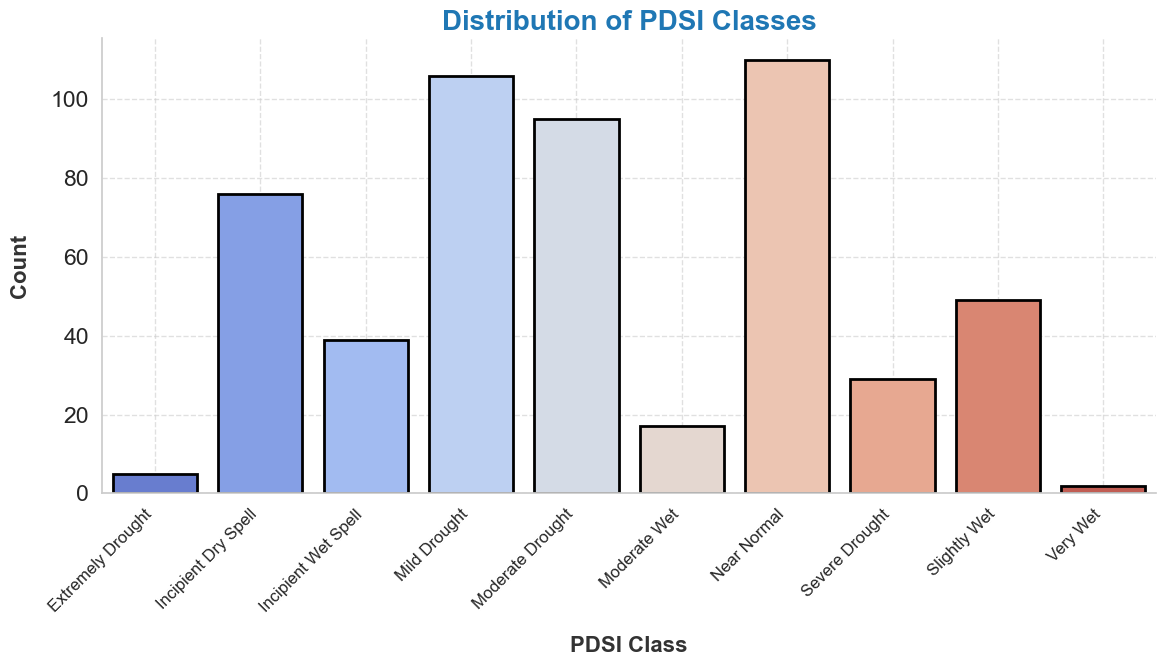

In [17]:
# Plot count of 'pdsi_encoded' with an enhanced style
plt.figure(figsize=(12, 7))

# Use a vibrant color palette and apply a custom style
sns.set(style="whitegrid", font_scale=1.5)
palette = sns.color_palette("coolwarm", len(df['pdsi_encoded'].unique()))

# Plot with enhanced aesthetics
sns.countplot(x='pdsi_encoded', data=df, palette=palette, edgecolor='black', linewidth=2)

# Map tick labels back to the original class names
tick_labels = le.inverse_transform(sorted(df['pdsi_encoded'].unique()))
plt.xticks(ticks=range(len(tick_labels)), labels=tick_labels, rotation=45, ha='right', fontsize=12)

# Customize axis labels and title with enhanced font and style
plt.xlabel('PDSI Class', fontsize=16, labelpad=15, fontweight='bold', color="#333333")
plt.ylabel('Count', fontsize=16, labelpad=15, fontweight='bold', color="#333333")
plt.title('Distribution of PDSI Classes', fontsize=20, fontweight='bold', color="#1f77b4")

# Remove top and right spines for cleaner look
sns.despine()

# Add background grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Improve layout and spacing
plt.tight_layout()
plt.savefig('Distribution_of_PDSI.PNG', dpi=300)
# Display the plot
plt.show()



## To get percentage of each unique value in the pdsi column

In [20]:
# Get the value counts of each unique value in the pdsi column
pdsi_counts = df['pdsi_class'].value_counts()

# Print the percentage of each unique value in the pdsi column
for pdsi, count in pdsi_counts.items():
    percent = (count / len(df)) * 100
    print(f"Percent of {pdsi.capitalize()}: {percent:.4f}%")

Percent of Near normal: 20.8333%
Percent of Mild drought: 20.0758%
Percent of Moderate drought: 17.9924%
Percent of Incipient dry spell: 14.3939%
Percent of Slightly wet: 9.2803%
Percent of Incipient wet spell: 7.3864%
Percent of Severe drought: 5.4924%
Percent of Moderate wet: 3.2197%
Percent of Extremely drought: 0.9470%
Percent of Very wet: 0.3788%
Percent of Extremely wet: 0.0000%


In [21]:
df[['aet','def','pet','pr','ro', 'soil','srad', 'tmmx', 'tmmn','vap', 'vpd', 'vs']].describe()

,aet,def,pet,pr,ro,soil,srad,tmmx,tmmn,vap,vpd,vs
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,52.176308,91.093566,143.270202,66.482229,52.176308,40.781468,234.578577,30.324968,16.244028,1.739231,1.479499,212.783970
std,23.820880,29.088747,12.010305,46.283567,23.820880,20.016804,19.413346,1.395183,1.483836,0.168231,0.248447,23.647993
min,5.017133,19.145580,110.534949,0.532765,5.017133,12.277166,180.351732,27.170480,12.390516,1.273199,1.038216,137.473604
25%,30.464633,67.554400,134.688967,23.160378,30.464633,22.085051,223.078124,29.360839,15.102498,1.588828,1.297659,194.858792
50%,58.401208,85.531689,141.363439,65.034771,58.401208,37.099272,235.329404,30.225111,16.731491,1.786939,1.444594,212.908668
75%,69.183632,114.226932,150.262112,102.812641,69.183632,60.477131,247.325777,31.181820,17.319257,1.878637,1.622680,230.897906
max,113.543985,167.460503,183.413895,186.408067,113.543985,82.461514,279.008024,34.878431,19.457821,2.043036,2.313077,263.804596


## Visualize the data distribution to explore

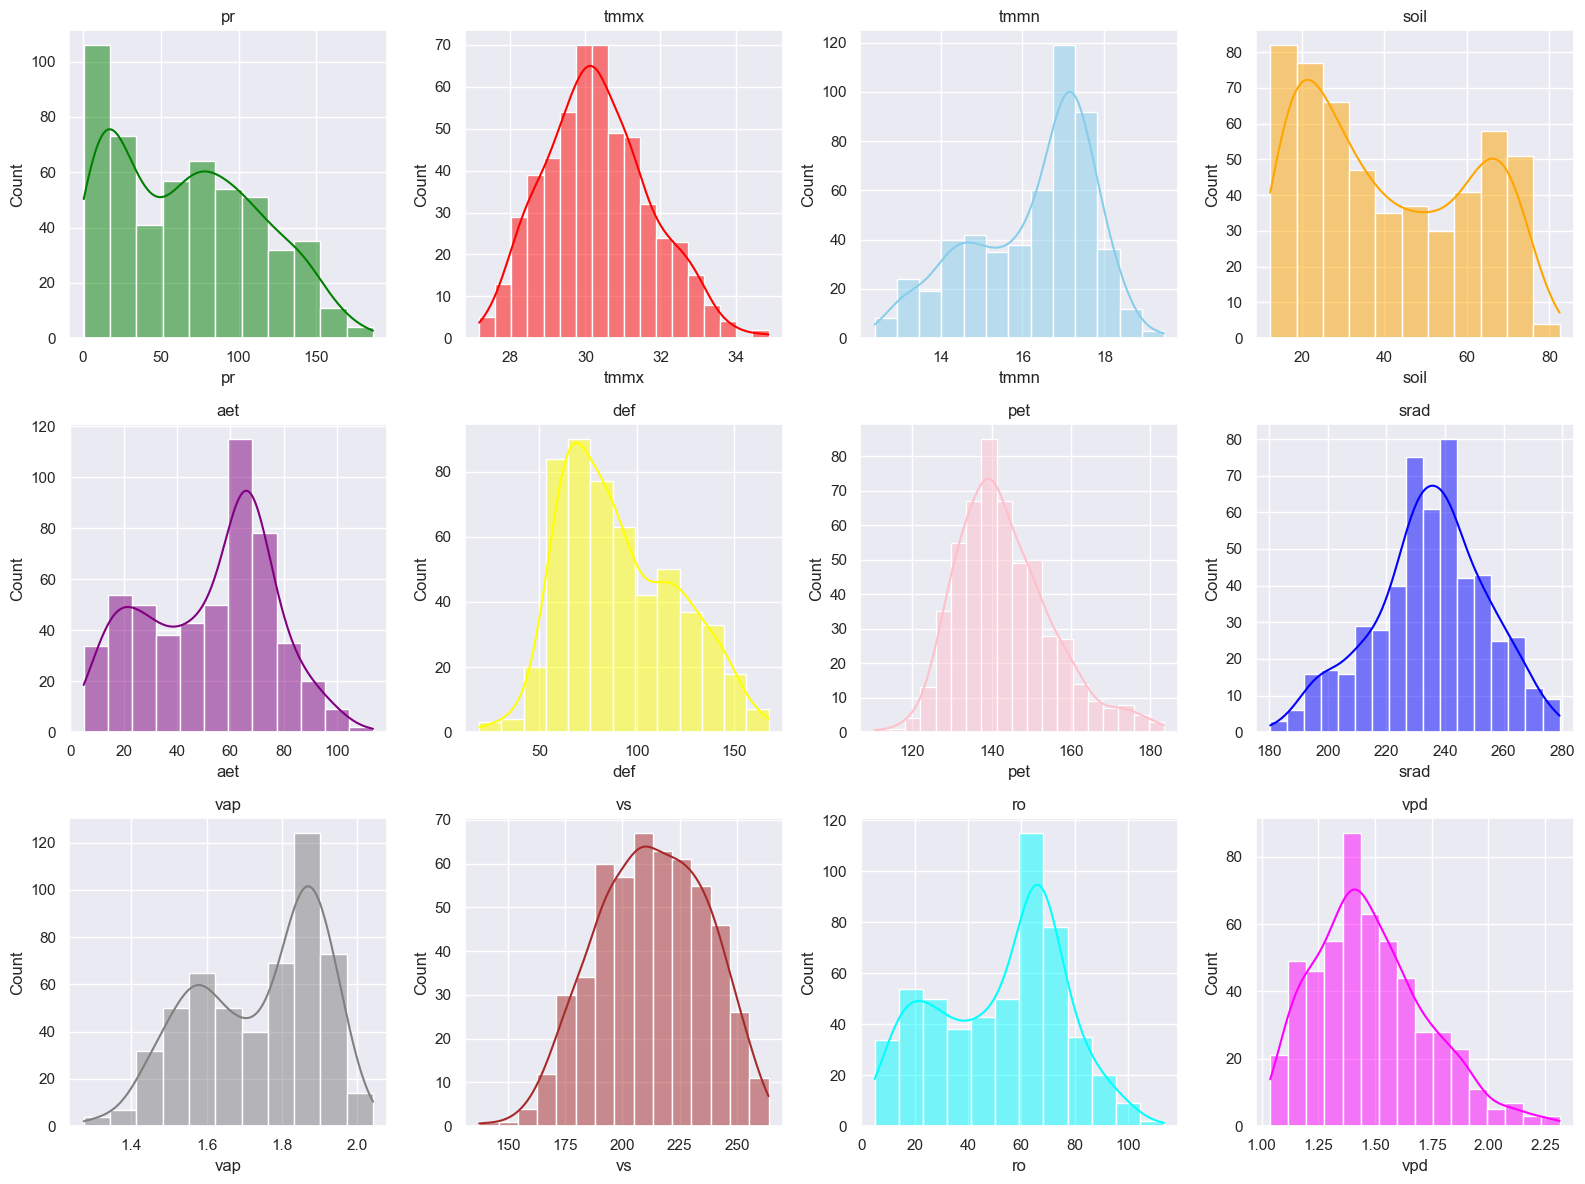

In [22]:
# Set the style for the plots
sns.set(style="darkgrid")

# Define the variables and colors for the subplots
variables = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]
colors = ["green", "red", "skyblue", "orange", "purple", "yellow", "pink", "blue", "gray", "brown", "cyan", "magenta"]

# Create the subplots using a loop - ensure grid is exactly 3x4 for 12 plots
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# Plot each variable
for i, var in enumerate(variables):
    row = i // 4
    col = i % 4
    sns.histplot(data=df, x=var, kde=True, ax=axs[row, col], color=colors[i])
    axs[row, col].set_title(var)

# Remove any extra subplots if the number of variables is less than grid size
if len(variables) < 3 * 4:
    for j in range(len(variables), 3 * 4):
        fig.delaxes(axs[j // 4, j % 4])

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()




In [18]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1981-01-01,8.110974,143.023862,151.136004,1.878243,8.110974,18.136619,253.863398,14.164818,30.774718,1.509087,1.610104,222.656243,Moderate Drought,4
1,1981-02-01,16.474987,130.389708,146.865089,13.466370,16.474987,14.459879,260.609263,14.572312,31.322946,1.456496,1.765419,231.999600,Severe Drought,7
2,1981-03-01,75.961518,62.851547,138.813319,94.600596,75.961518,27.165537,220.083588,17.117157,29.780160,1.620867,1.563144,177.824586,Mild Drought,3
3,1981-04-01,86.065355,56.230348,142.295486,118.330921,86.065355,42.538872,245.811232,17.084674,29.753378,1.715492,1.463258,176.660039,Near Normal,6
4,1981-05-01,65.481602,88.917063,154.399204,65.913244,65.481602,38.543301,251.227387,17.217060,30.373915,1.849225,1.415150,224.176060,Near Normal,6


# Time Series Trend for Each Variable

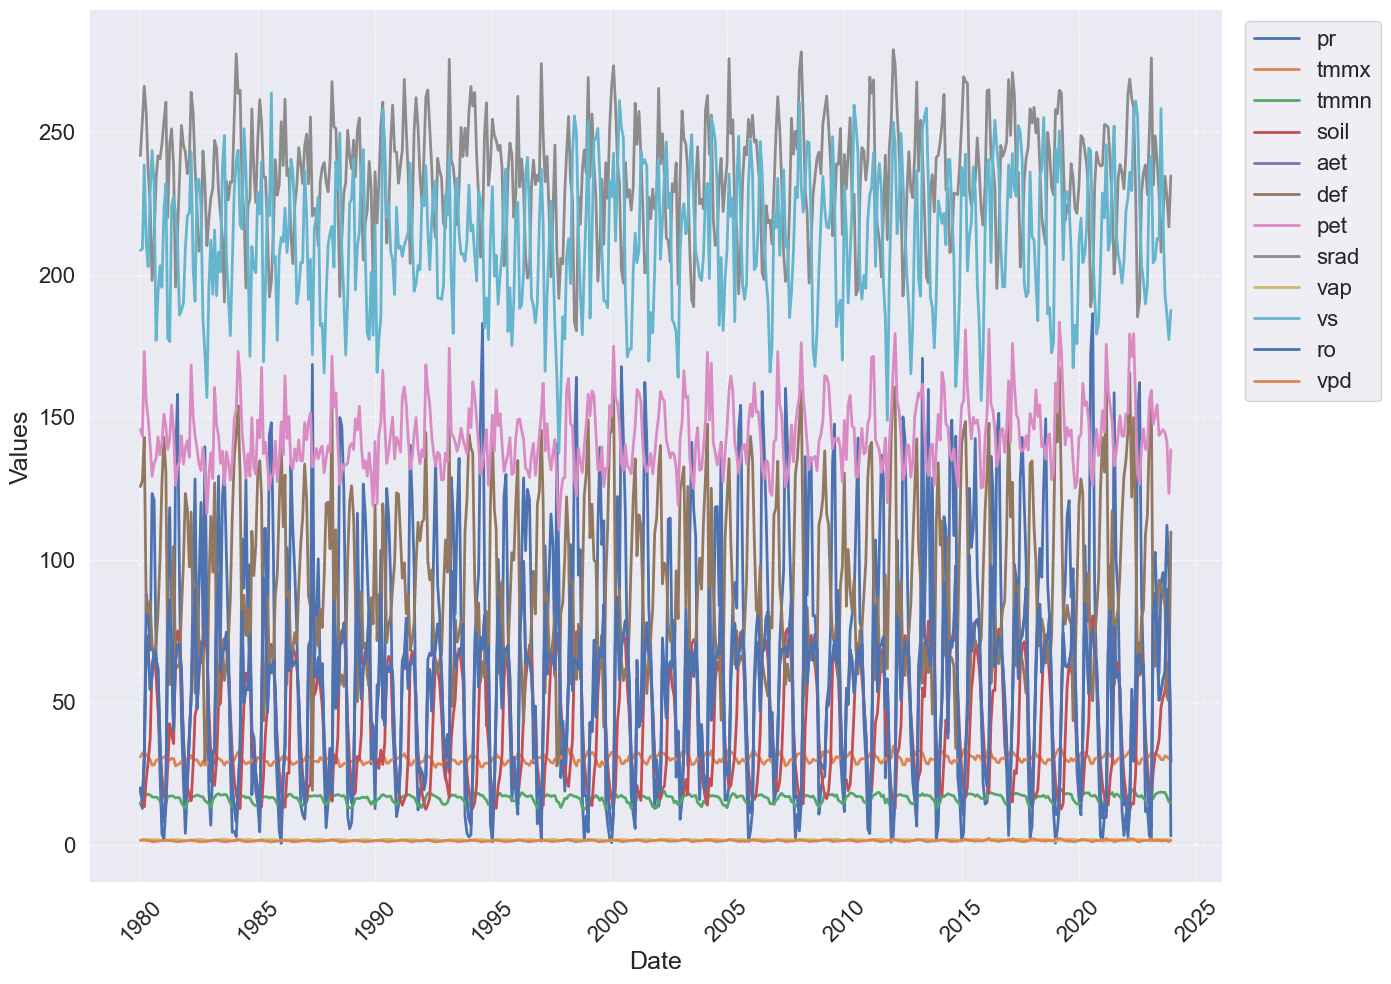

In [23]:
# We are going to use the copy of df
df_time_series=df.copy()

# # Drop the non-numeric columns for plotting
df_time_series = df.drop(columns=['pdsi_class', 'pdsi_encoded'], errors='ignore')
df_time_series.head()
# # Ensure 'date' column is in datetime format
df_time_series['Date'] = pd.to_datetime(df_time_series['Date'], errors='coerce')
df_time_series.dtypes

# List of variables to plot
variables_to_plot = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]

# Set up the plot
plt.figure(figsize=(14, 10))

# Plot each specified variable
for column in variables_to_plot:
    if column in df_time_series.columns:
        plt.plot(df_time_series['Date'], df_time_series[column], label=column, linewidth=2)

# Customize the plot
plt.xlabel('Date', fontsize=18)
plt.ylabel('Values', fontsize=18)
plt.xticks(fontsize=16, rotation=45)  # Rotate x-ticks for better visibility
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=16, loc='upper right', bbox_to_anchor=(1.15, 1))

# Remove the right and top spines
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Save the figure with proper settings
plt.tight_layout()
plt.savefig('Time_Series_Analysis_TerraClimate_new.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [24]:
df_time_series.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs
0,1980-01-01,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280
1,1980-02-01,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518
2,1980-03-01,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892
3,1980-04-01,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787
4,1980-05-01,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194


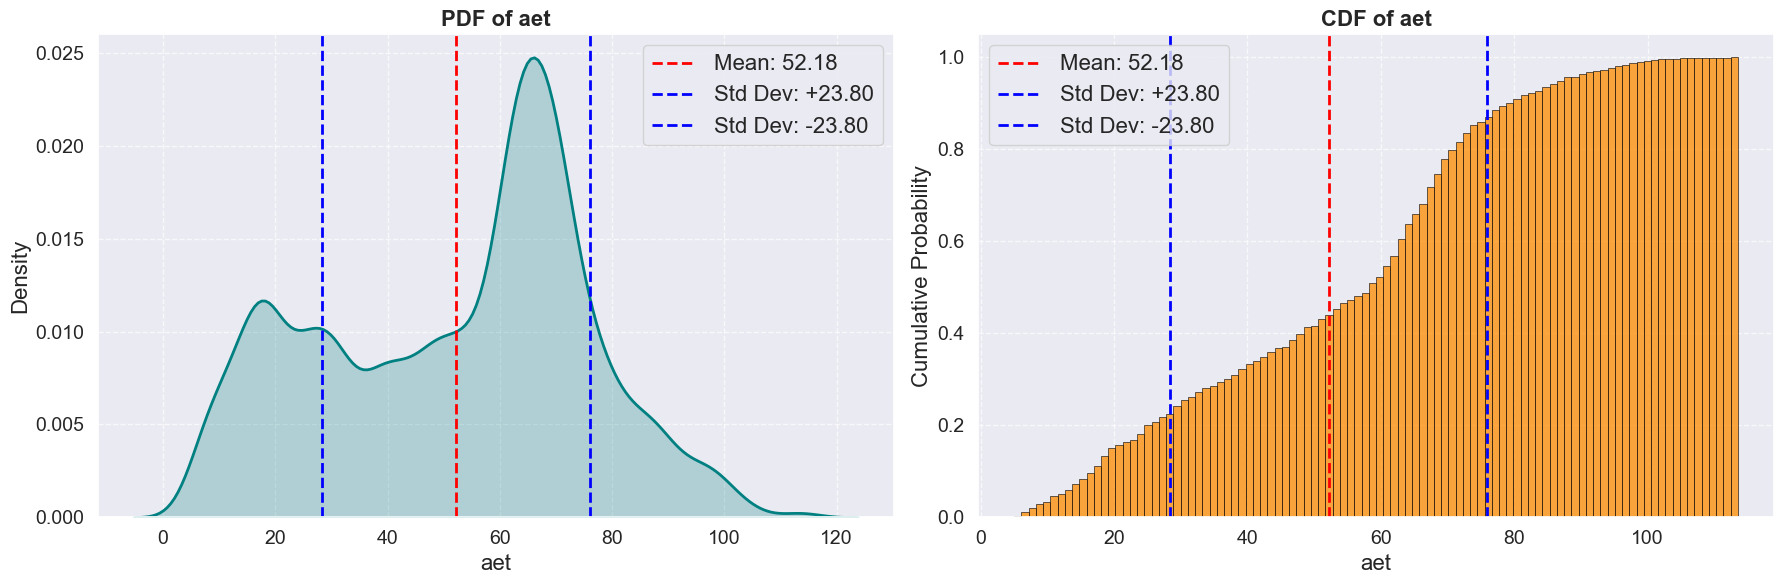

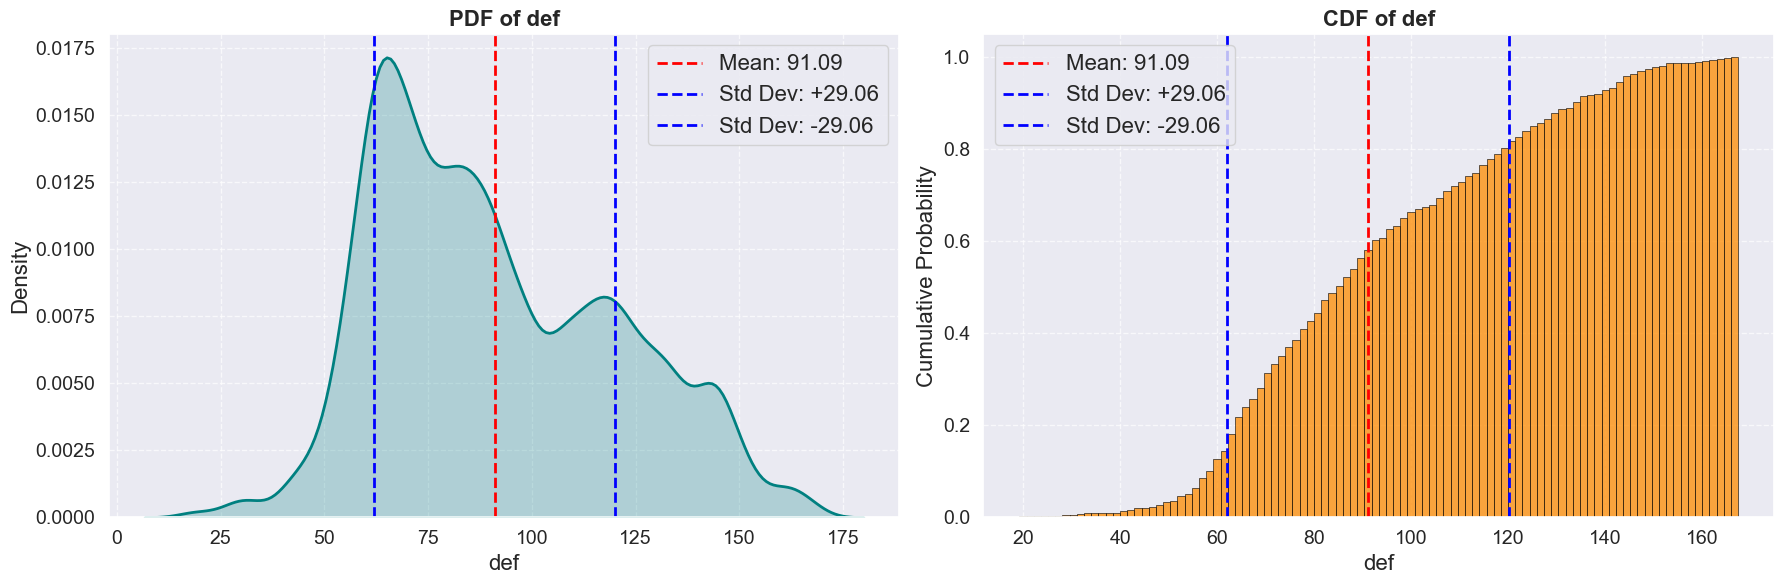

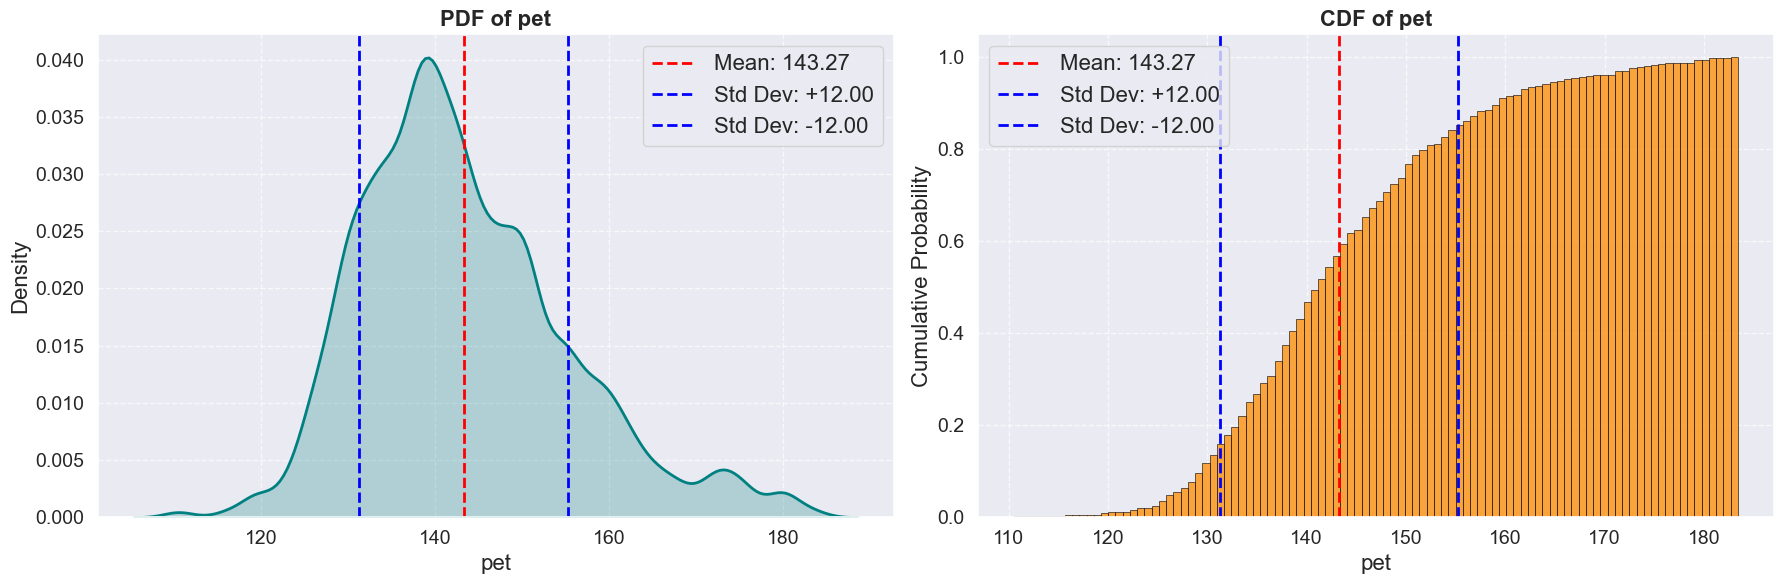

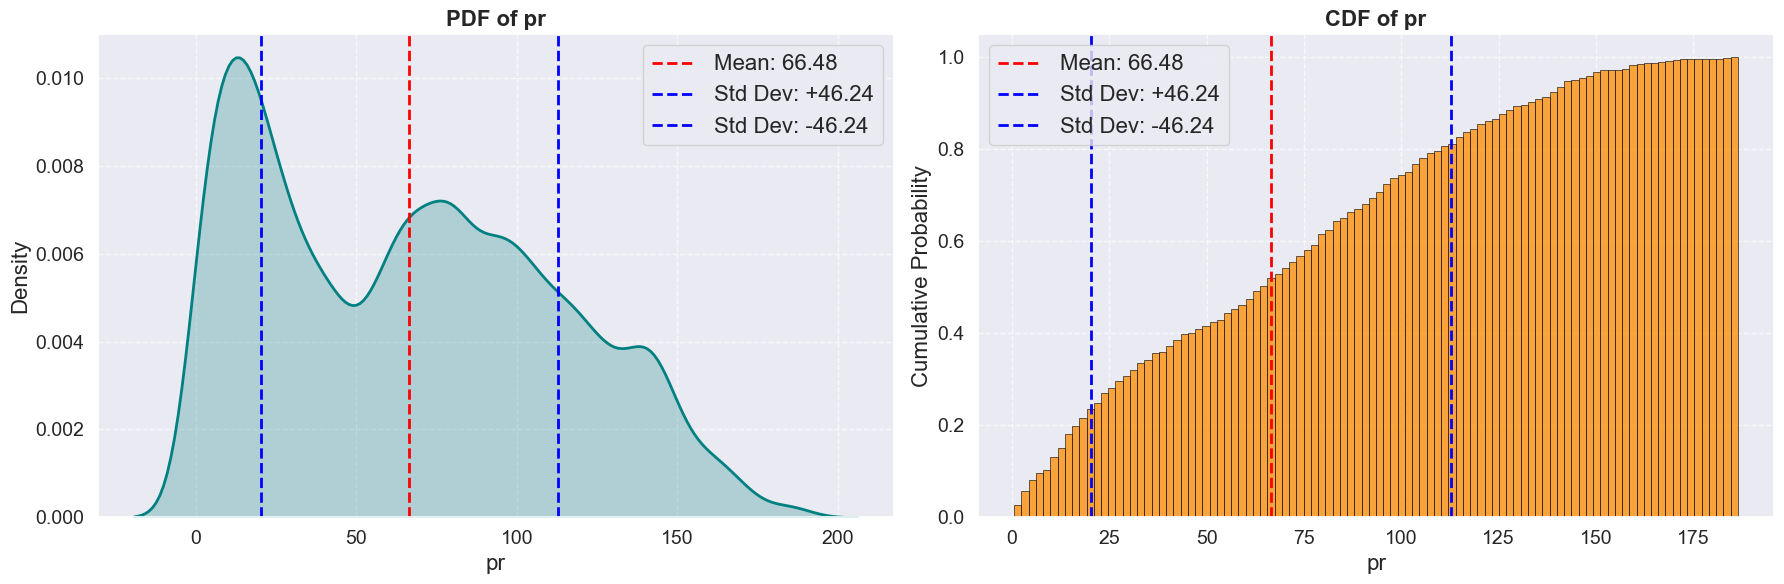

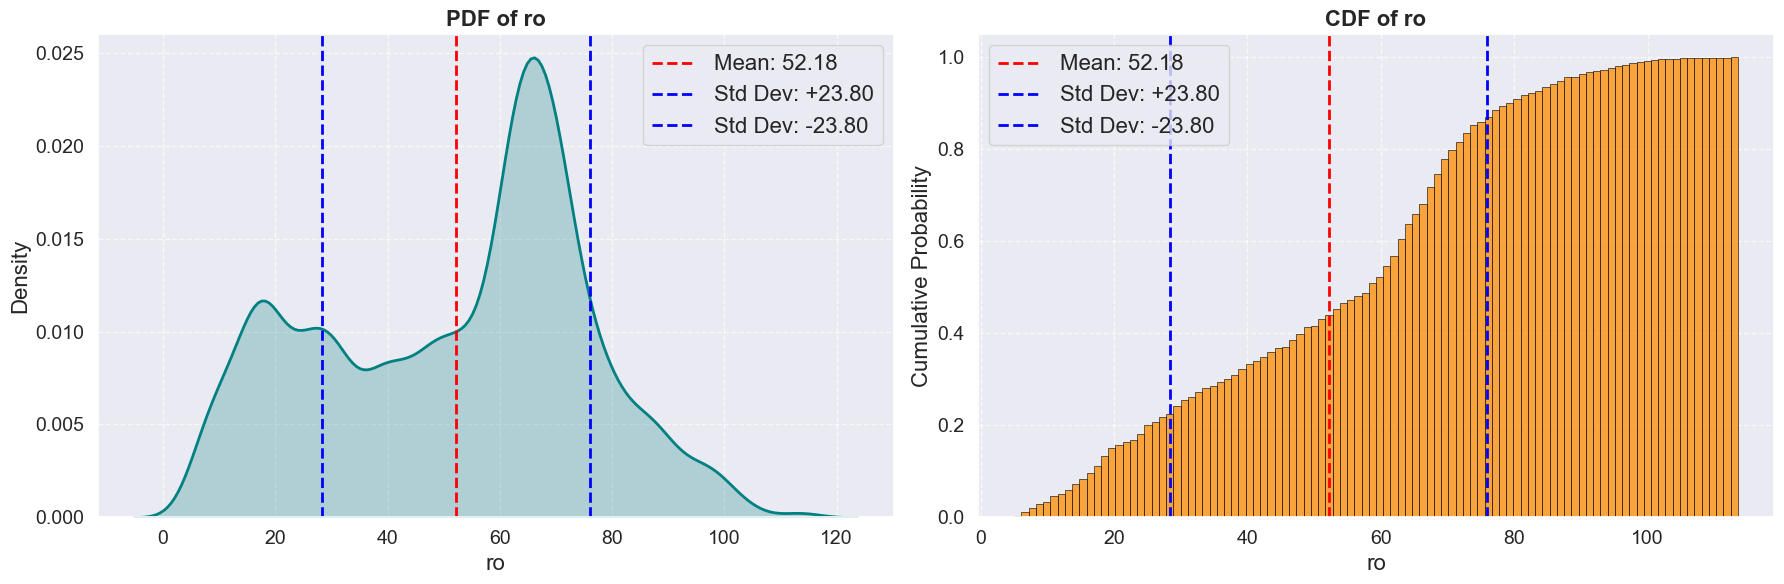

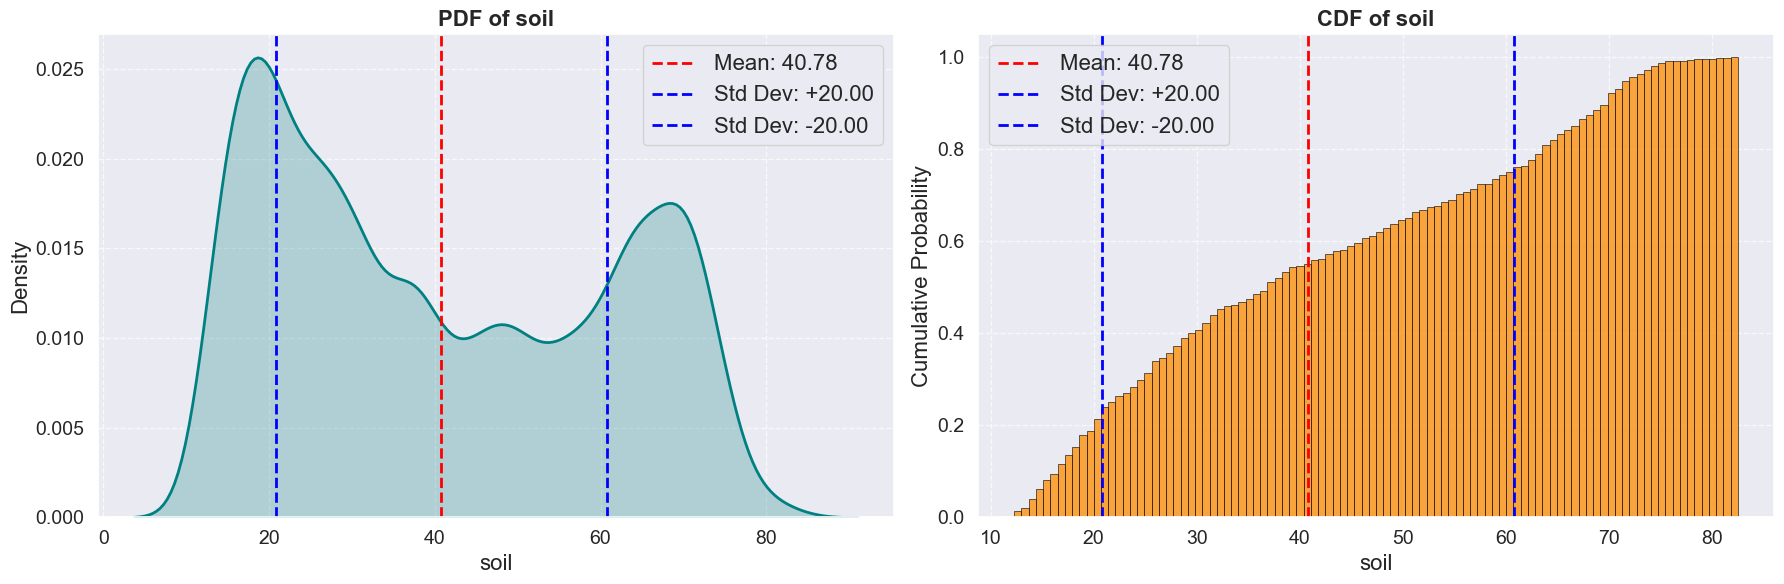

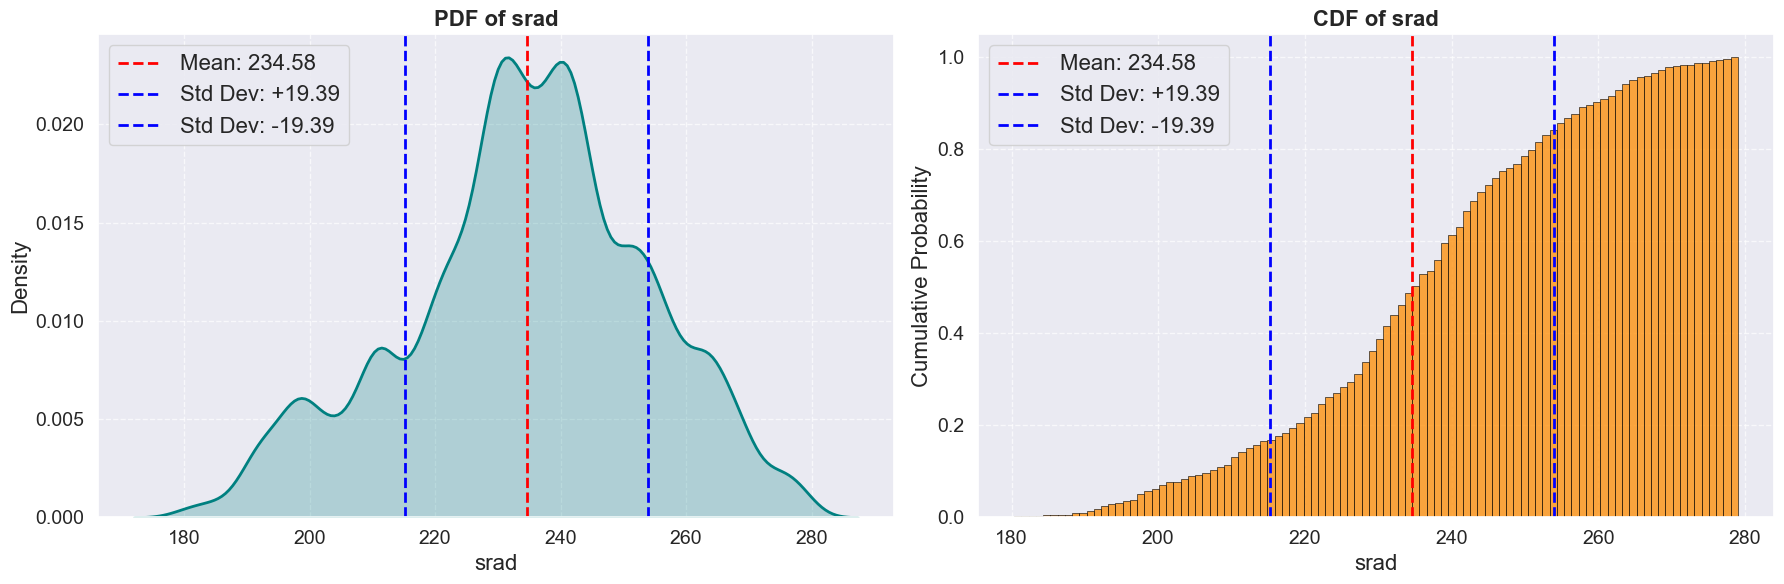

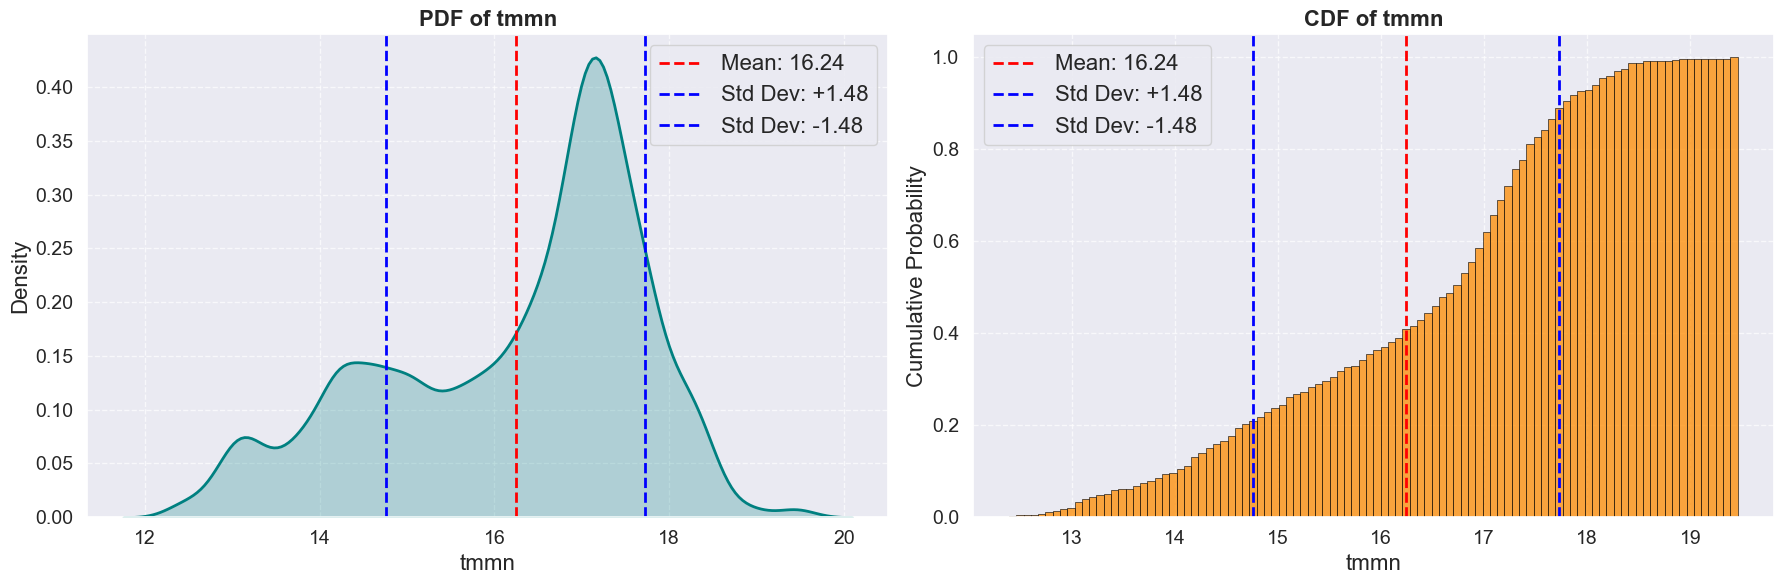

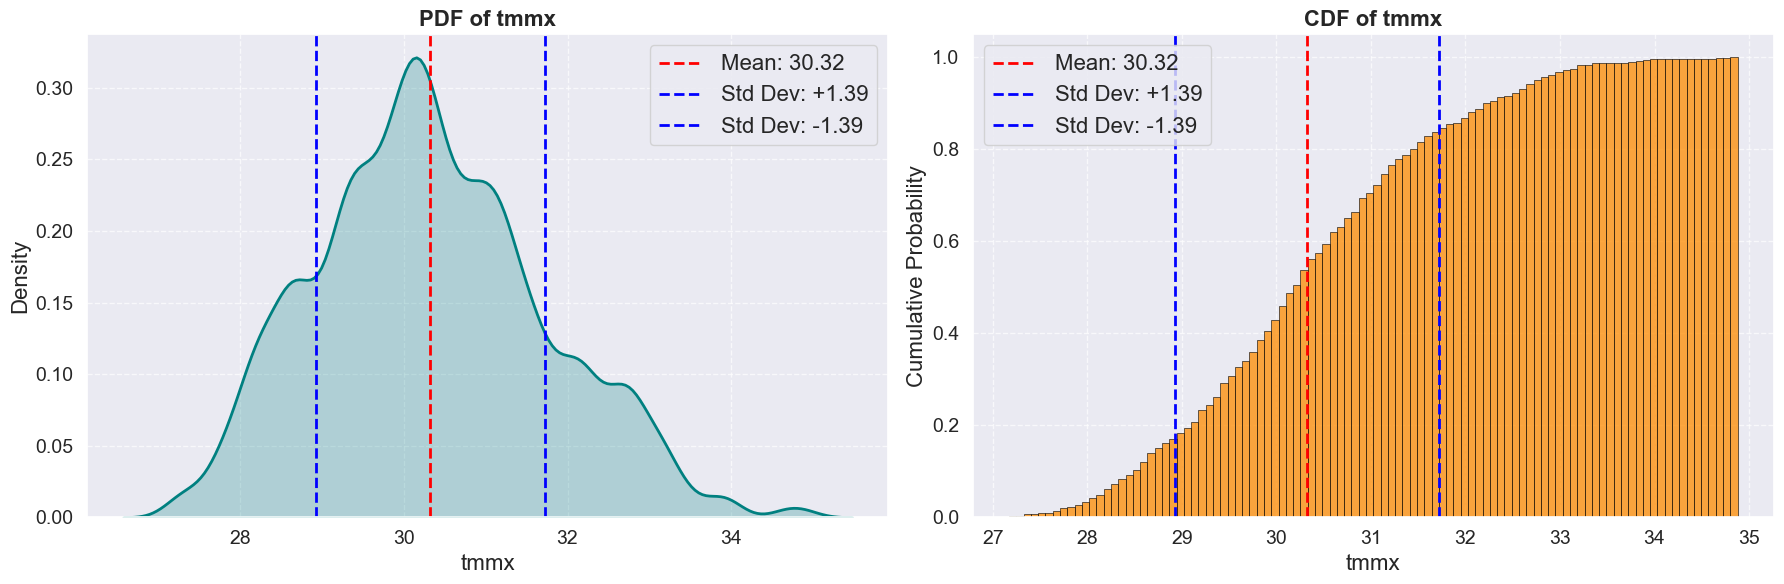

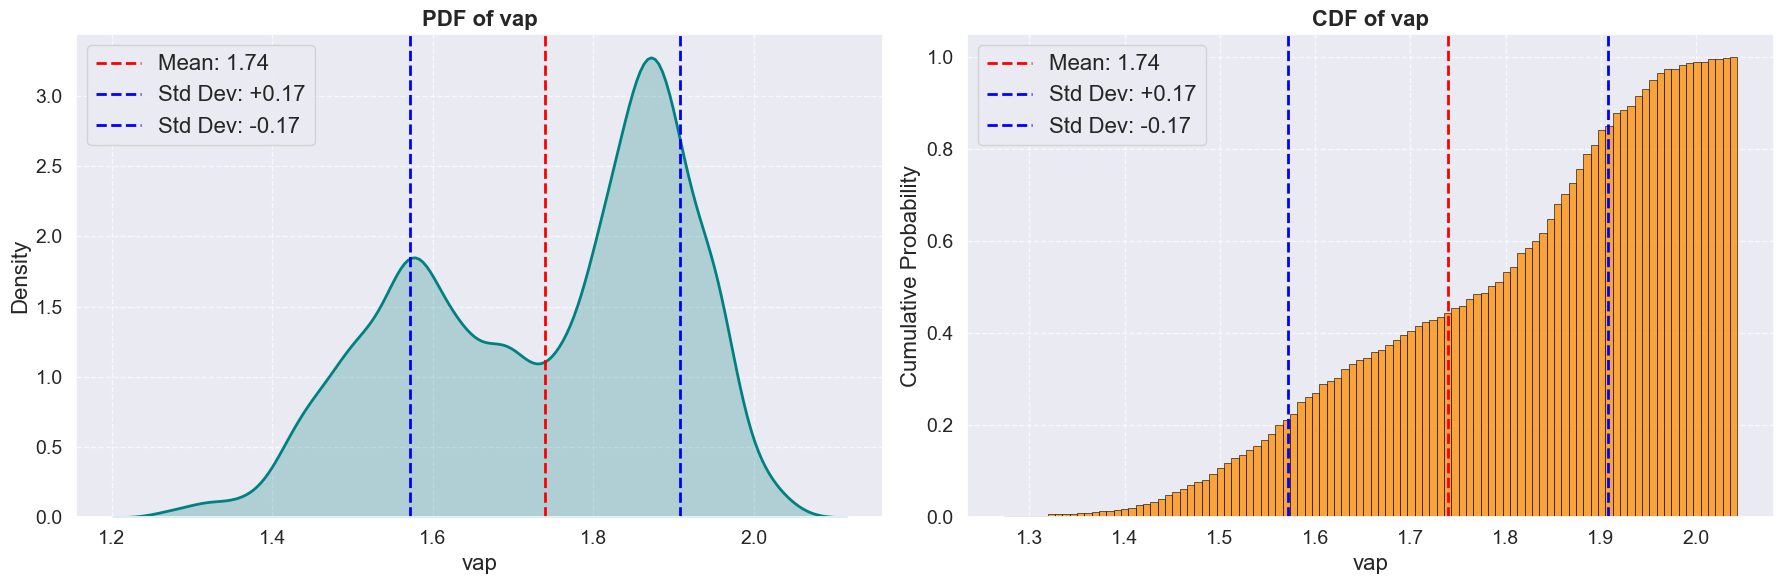

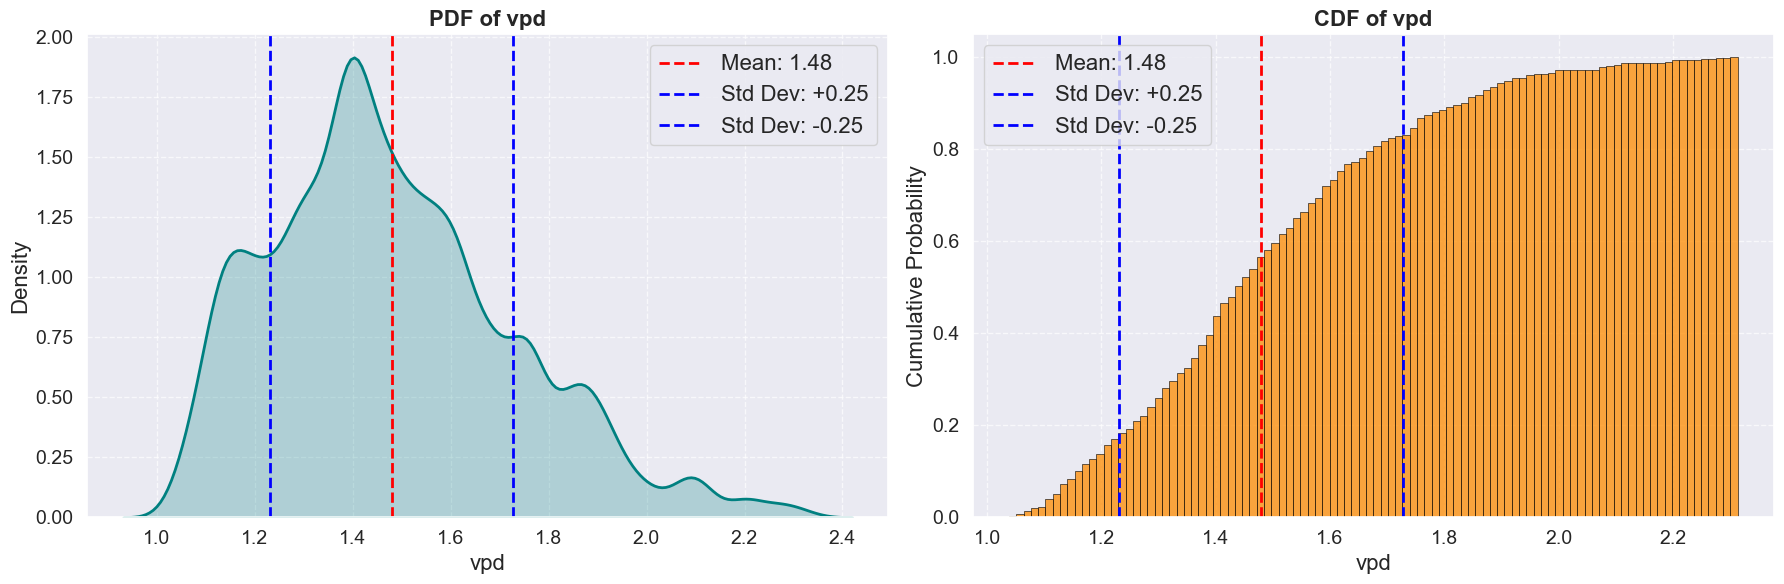

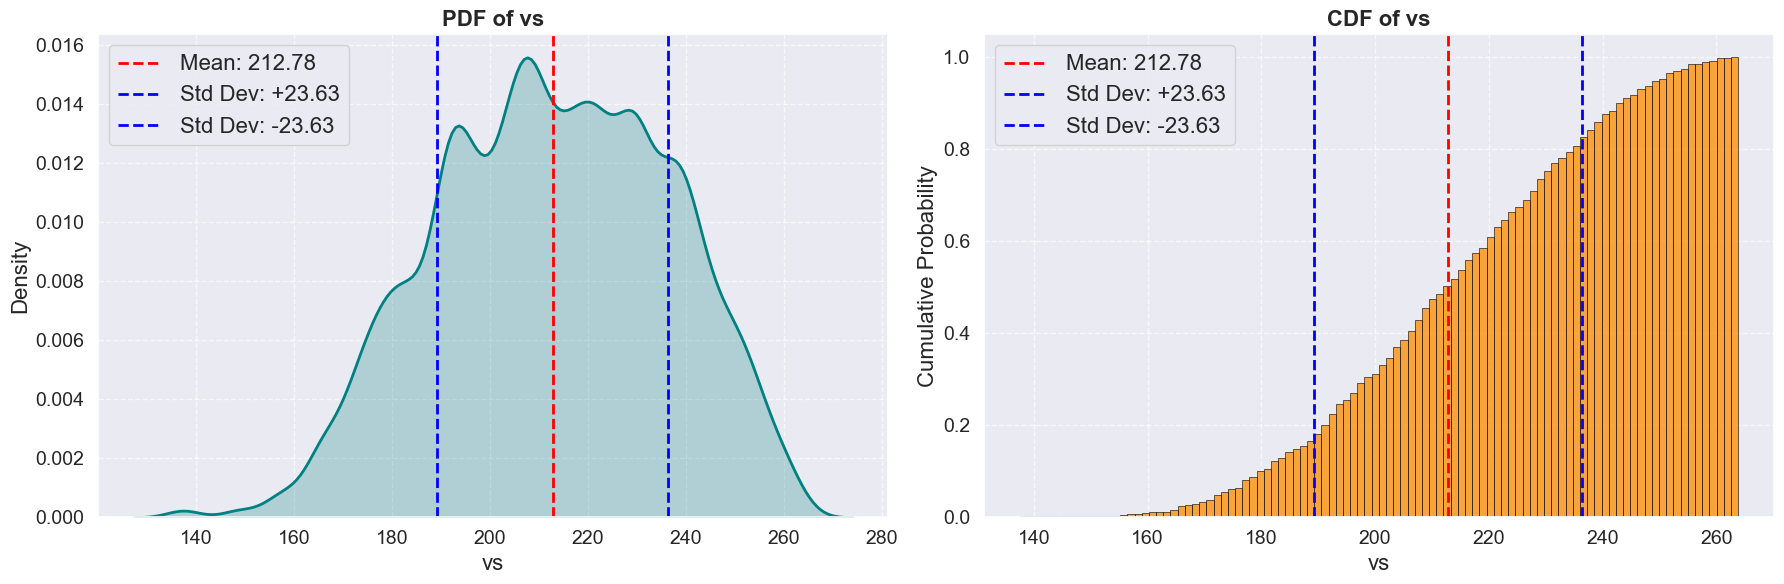

In [25]:
df_pdf_cdf = df_time_series.drop(columns=['pdsi_class', 'pdsi_encoded', 'Date'], errors='ignore')

# Set up the figure with two subplots side by side for each variable
for column in df_pdf_cdf.columns:
    mean = np.mean(df_pdf_cdf[column])
    std_dev = np.std(df_pdf_cdf[column])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot PDF on the first subplot
    sns.kdeplot(df_pdf_cdf[column], bw_adjust=0.5, fill=True, ax=axes[0], color="teal", linewidth=2)
    axes[0].axvline( mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
    axes[0].axvline(mean + std_dev, color='blue', linestyle='--', linewidth=2, label=f'Std Dev: +{std_dev:.2f}')
    axes[0].axvline(mean - std_dev, color='blue', linestyle='--', linewidth=2, label=f'Std Dev: -{std_dev:.2f}')
    axes[0].set_title(f'PDF of {column}', fontsize=16, fontweight='bold')
    axes[0].set_xlabel(column, fontsize=16)
    axes[0].set_ylabel('Density', fontsize=16)
    axes[0].tick_params(axis='both', which='major', labelsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend(fontsize=16)

    # Plot CDF on the second subplot
    sns.histplot(df_pdf_cdf[column], cumulative=True, stat='density', kde=False, bins=100, ax=axes[1], color="darkorange", edgecolor="black")
    axes[1].axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
    axes[1].axvline(mean + std_dev, color='blue', linestyle='--', linewidth=2, label=f'Std Dev: +{std_dev:.2f}')
    axes[1].axvline(mean - std_dev, color='blue', linestyle='--', linewidth=2, label=f'Std Dev: -{std_dev:.2f}')
    axes[1].set_title(f'CDF of {column}', fontsize=16, fontweight='bold')
    axes[1].set_xlabel(column, fontsize=16)
    axes[1].set_ylabel('Cumulative Probability', fontsize=16)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend(fontsize=16)

    # Enhance layout and show the plots
    plt.tight_layout()
    plt.show()


## Explore and detect the outliers using Boxplot

In [22]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1981-01-01,8.110974,143.023862,151.136004,1.878243,8.110974,18.136619,253.863398,14.164818,30.774718,1.509087,1.610104,222.656243,Moderate Drought,4
1,1981-02-01,16.474987,130.389708,146.865089,13.466370,16.474987,14.459879,260.609263,14.572312,31.322946,1.456496,1.765419,231.999600,Severe Drought,7
2,1981-03-01,75.961518,62.851547,138.813319,94.600596,75.961518,27.165537,220.083588,17.117157,29.780160,1.620867,1.563144,177.824586,Mild Drought,3
3,1981-04-01,86.065355,56.230348,142.295486,118.330921,86.065355,42.538872,245.811232,17.084674,29.753378,1.715492,1.463258,176.660039,Near Normal,6
4,1981-05-01,65.481602,88.917063,154.399204,65.913244,65.481602,38.543301,251.227387,17.217060,30.373915,1.849225,1.415150,224.176060,Near Normal,6


In [26]:
df_outlier = df.copy()
df_outlier.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1980-01-01,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280,Mild Drought,3
1,1980-02-01,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518,Mild Drought,3
2,1980-03-01,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892,Moderate Drought,4
3,1980-04-01,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787,Mild Drought,3
4,1980-05-01,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194,Mild Drought,3


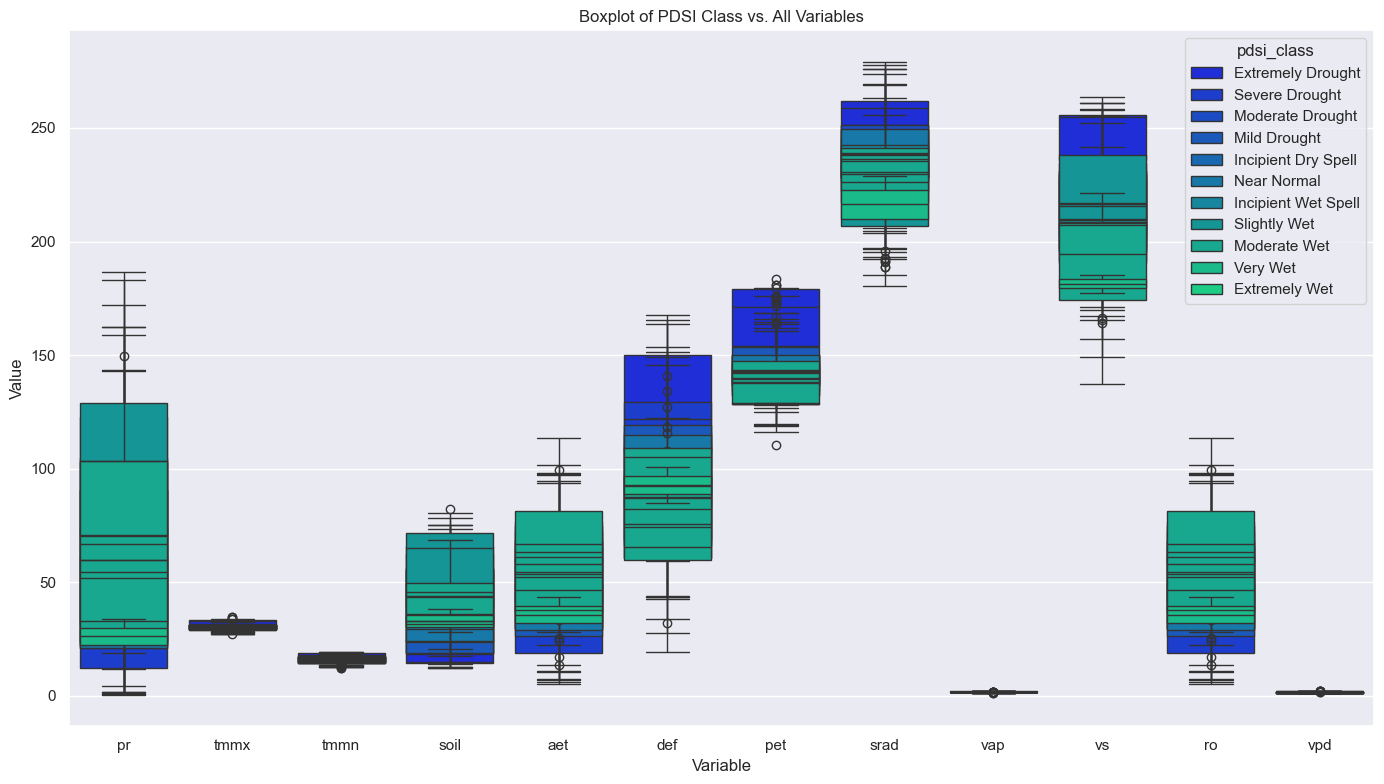

In [27]:
# Assuming df_outlier is your original DataFrame
variables = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]

# Melt the dataframe to have 'variable' and 'value' columns
df_melted = pd.melt(df_outlier, id_vars=["pdsi_class"], value_vars=variables, 
                    var_name="Variable", value_name="Value")

# Create the boxplot for all variables
plt.figure(figsize=(14, 8))
sns.boxplot(x="Variable", y="Value", hue="pdsi_class", data=df_melted, palette="winter", dodge=False)

# Set axis labels and title
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Boxplot of PDSI Class vs. All Variables')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\LEBELA TADELE MELESE\AppData\Local\Temp\ipykernel_548\403643150.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', len(df_outlier['pdsi_class'].unique()))
C:\Users\LEBELA TADELE MELESE\AppData\Local\Temp\ipykernel_548\403643150.py:22: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x="Variable", y="Value", hue="pdsi_class", data=df_melted, palette=palette, dodge=False)


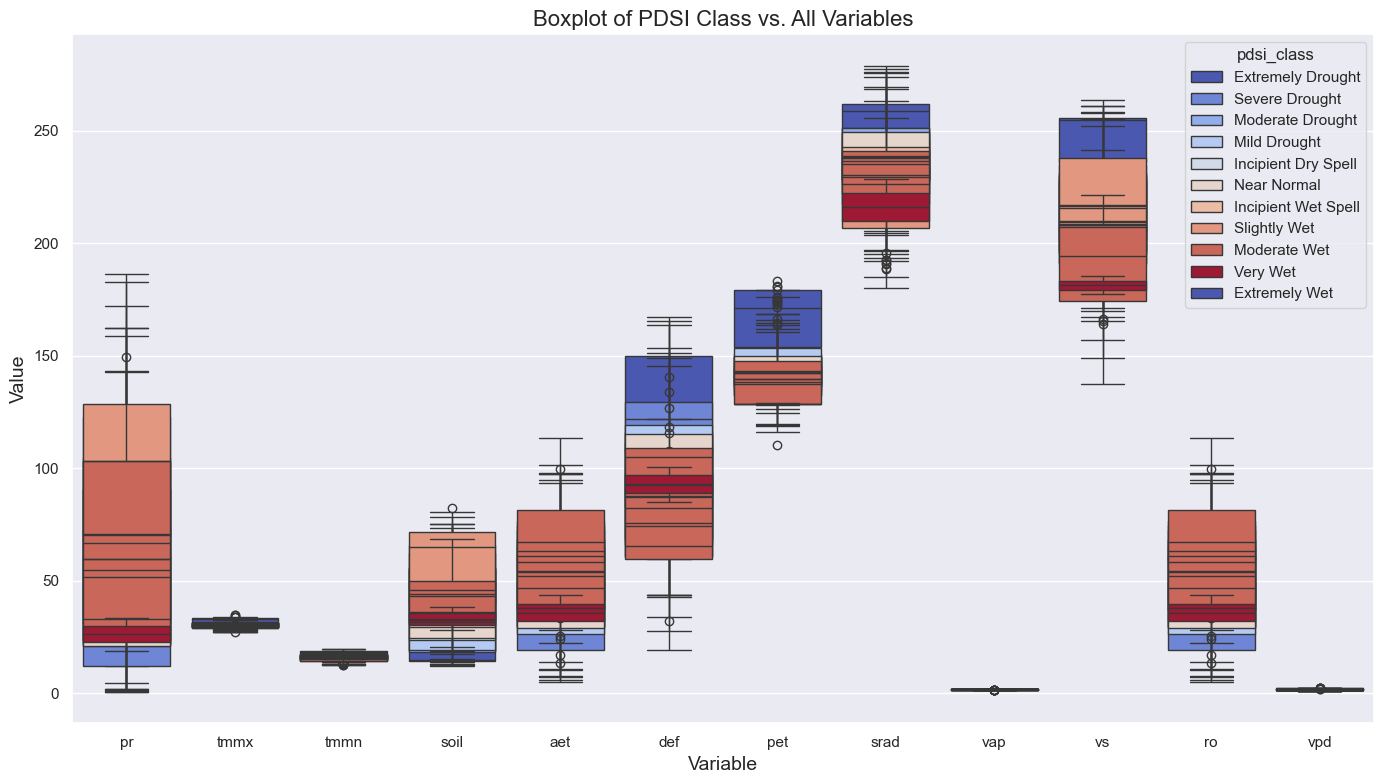

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# Example DataFrame
# df_outlier = pd.DataFrame({...})  # Your DataFrame here

variables = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]

# Convert colormap to list of colors
cmap = cm.get_cmap('coolwarm', len(df_outlier['pdsi_class'].unique()))
palette = [cmap(i) for i in np.linspace(0, 1, len(df_outlier['pdsi_class'].unique()))]

# Melt the dataframe
df_melted = pd.melt(df_outlier, id_vars=["pdsi_class"], value_vars=variables, 
                    var_name="Variable", value_name="Value")

# Create the boxplot for all variables
plt.figure(figsize=(14, 8))
sns.boxplot(x="Variable", y="Value", hue="pdsi_class", data=df_melted, palette=palette, dodge=False)

# Set axis labels and title
plt.xlabel('Variable', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.title('Boxplot of PDSI Class vs. All Variables', fontsize=16)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()



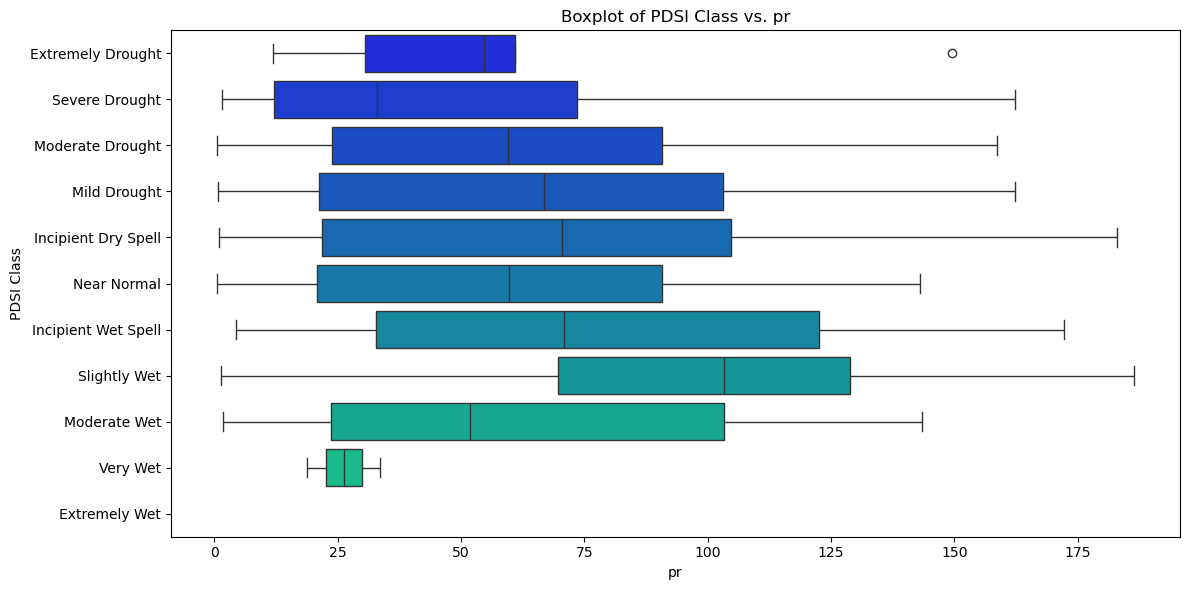

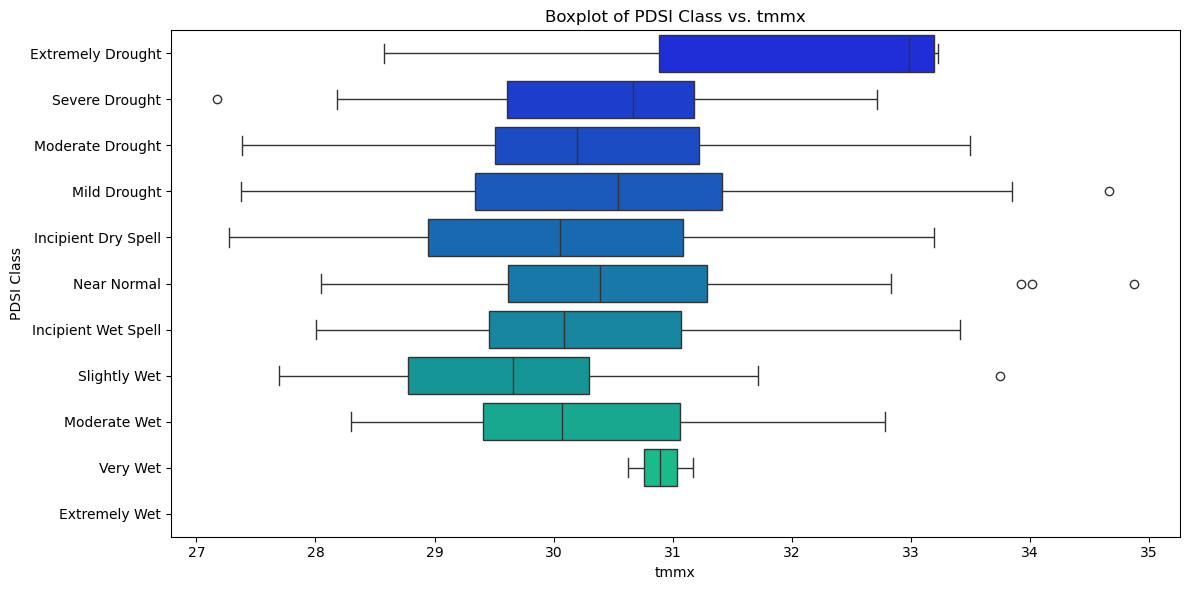

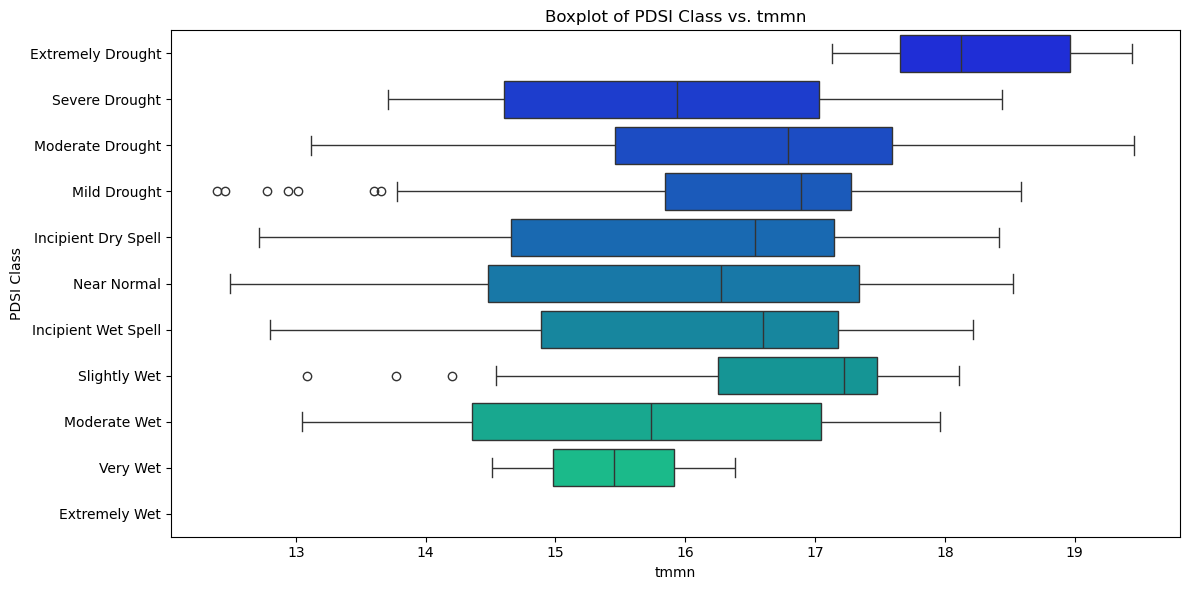

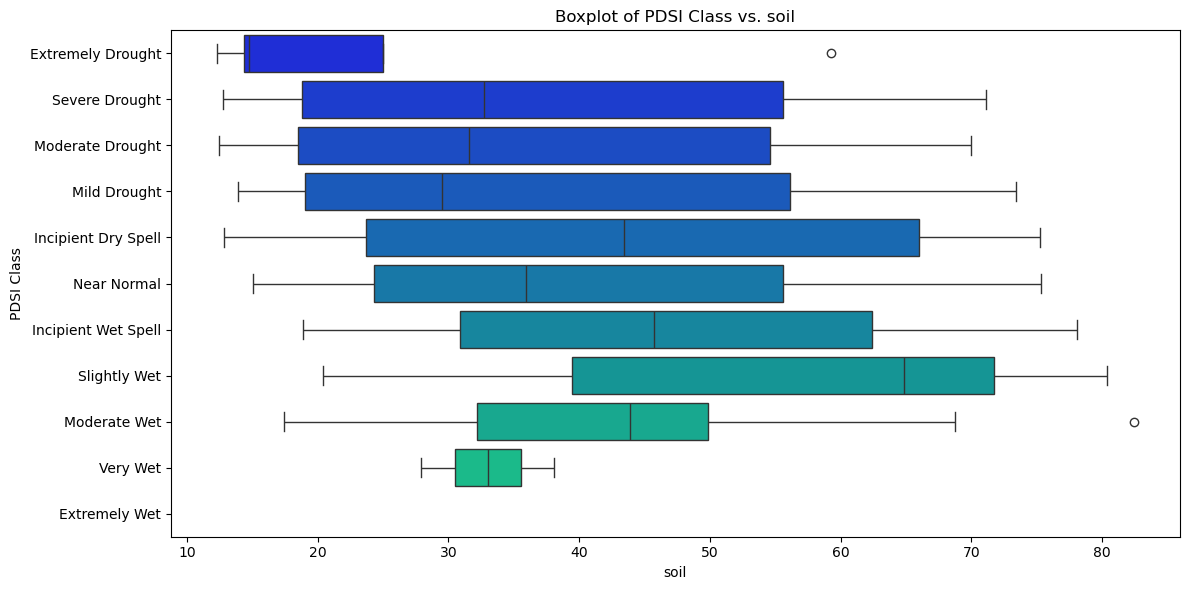

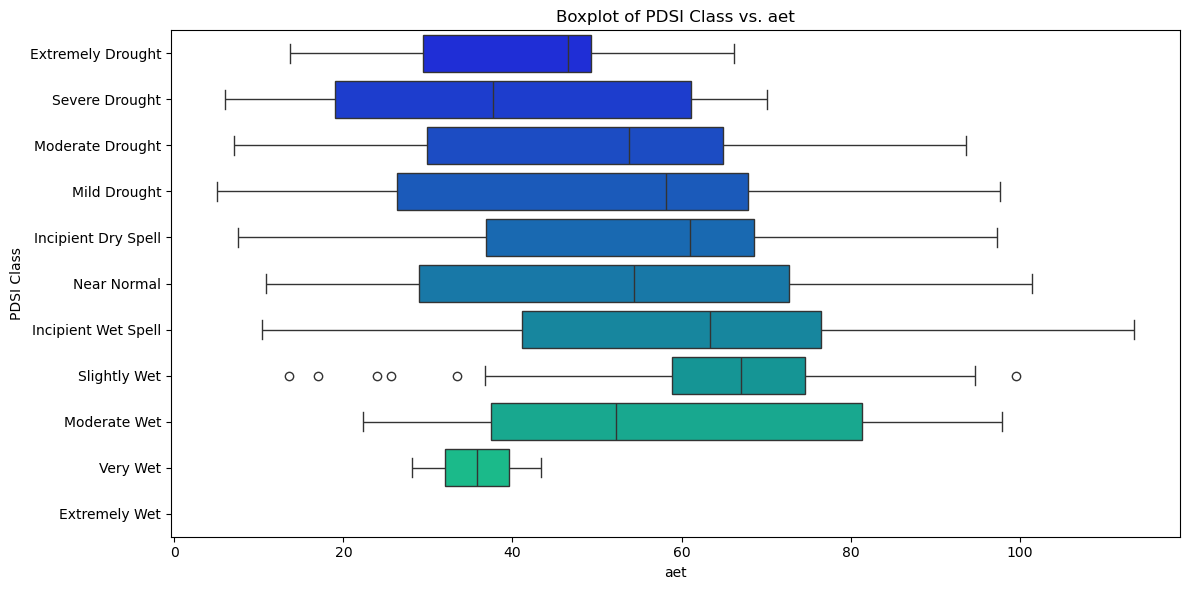

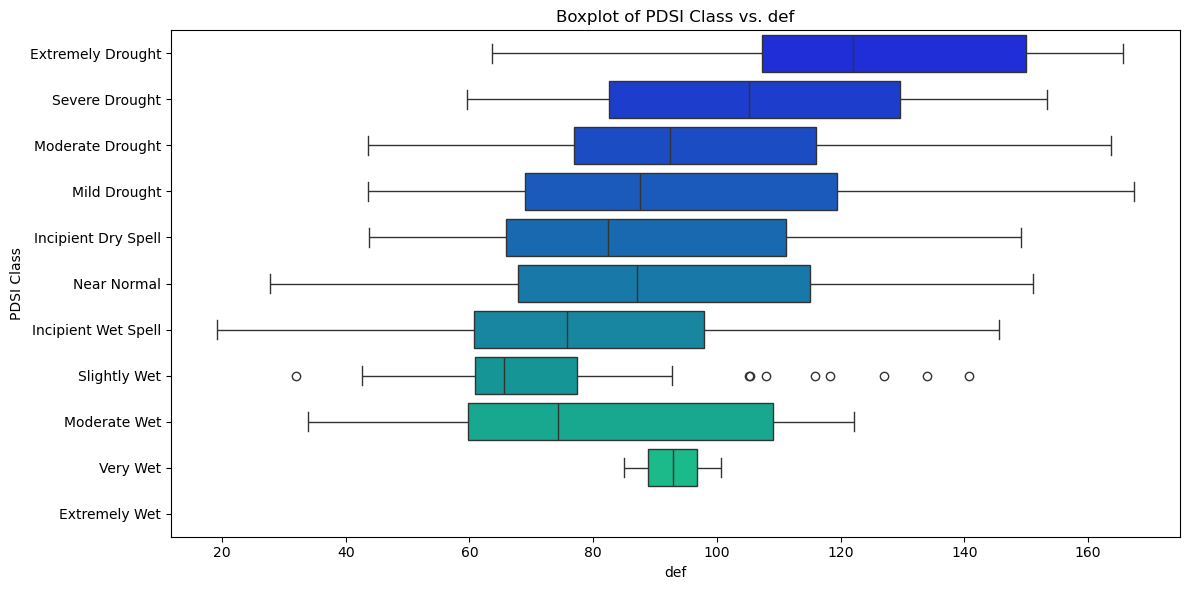

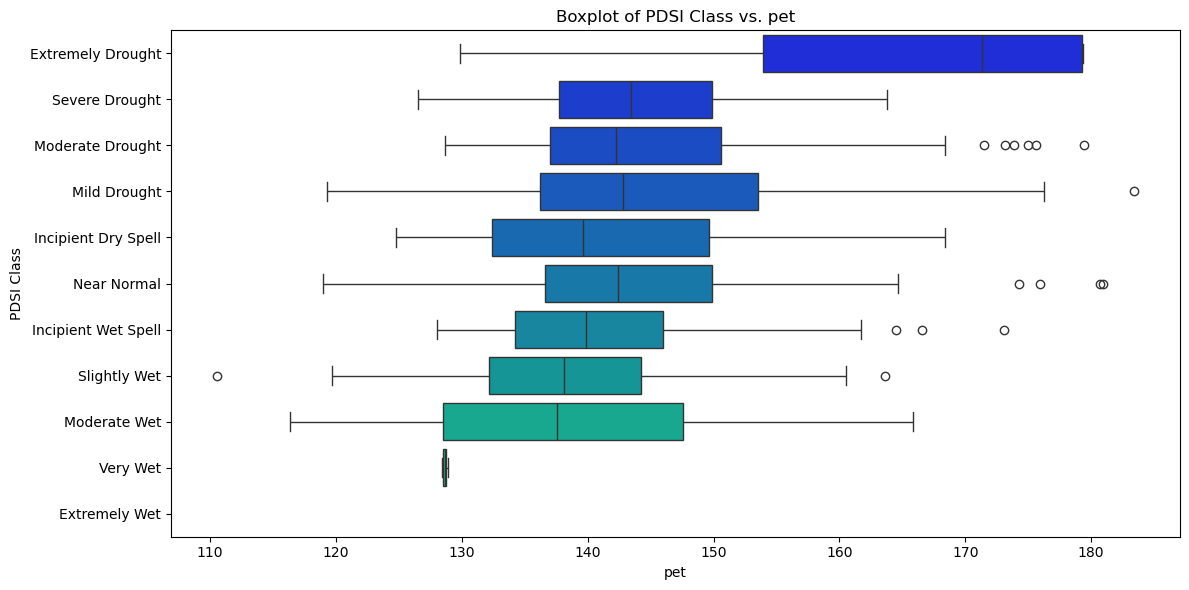

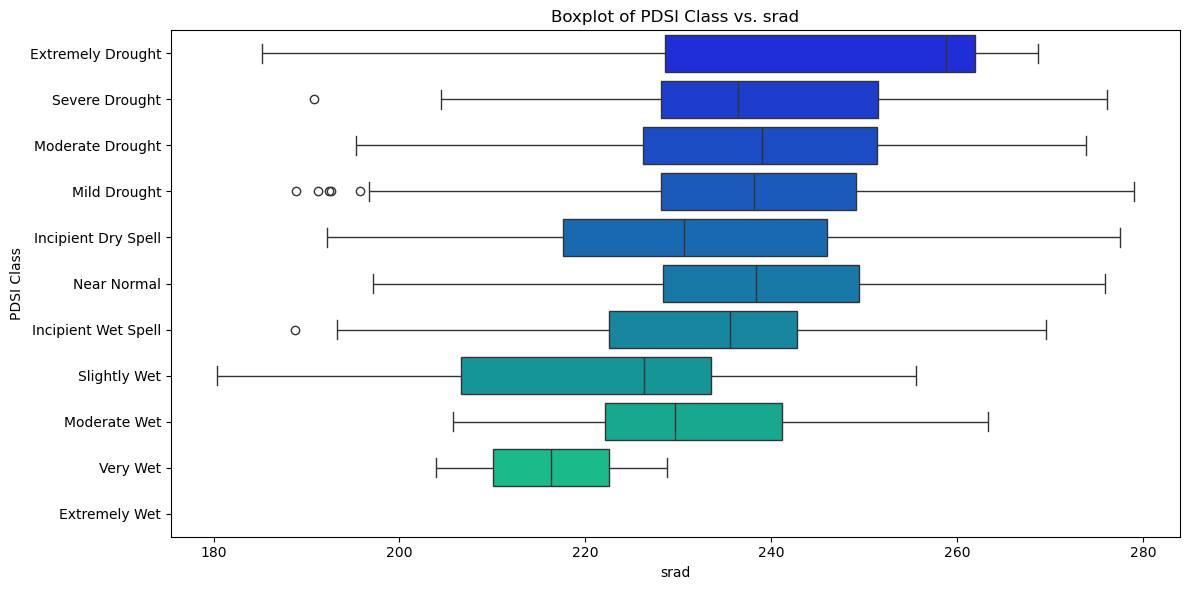

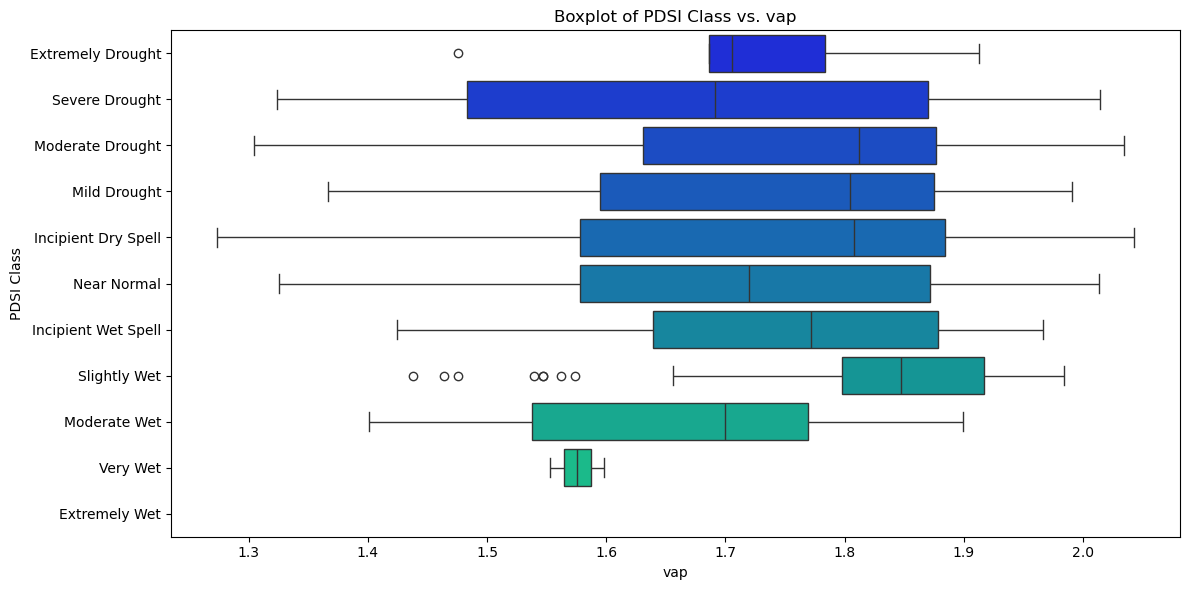

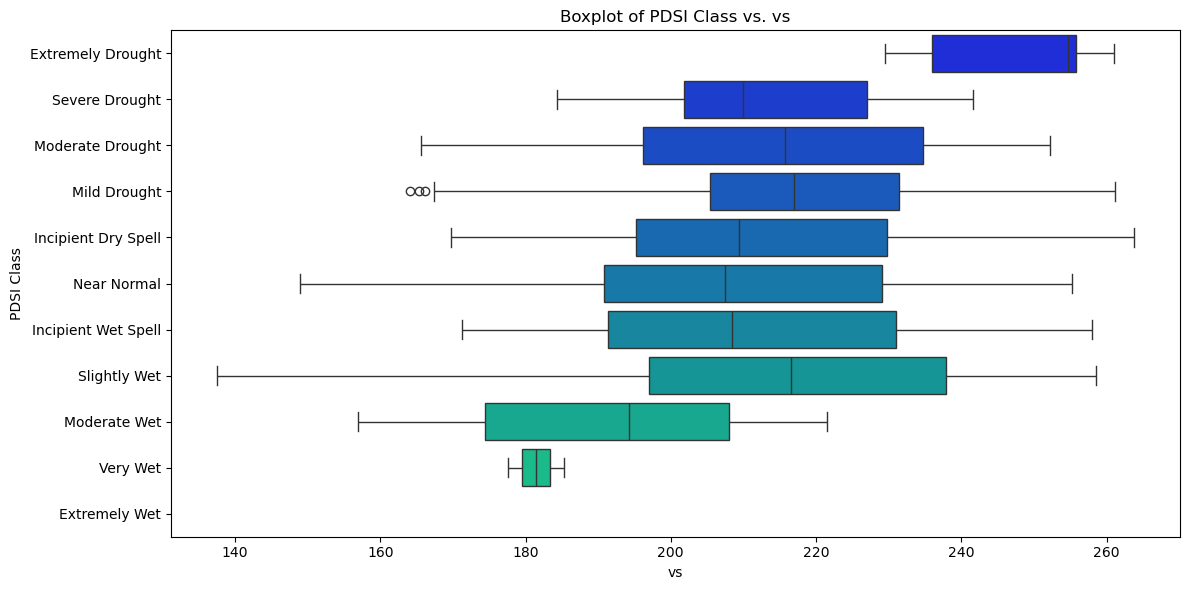

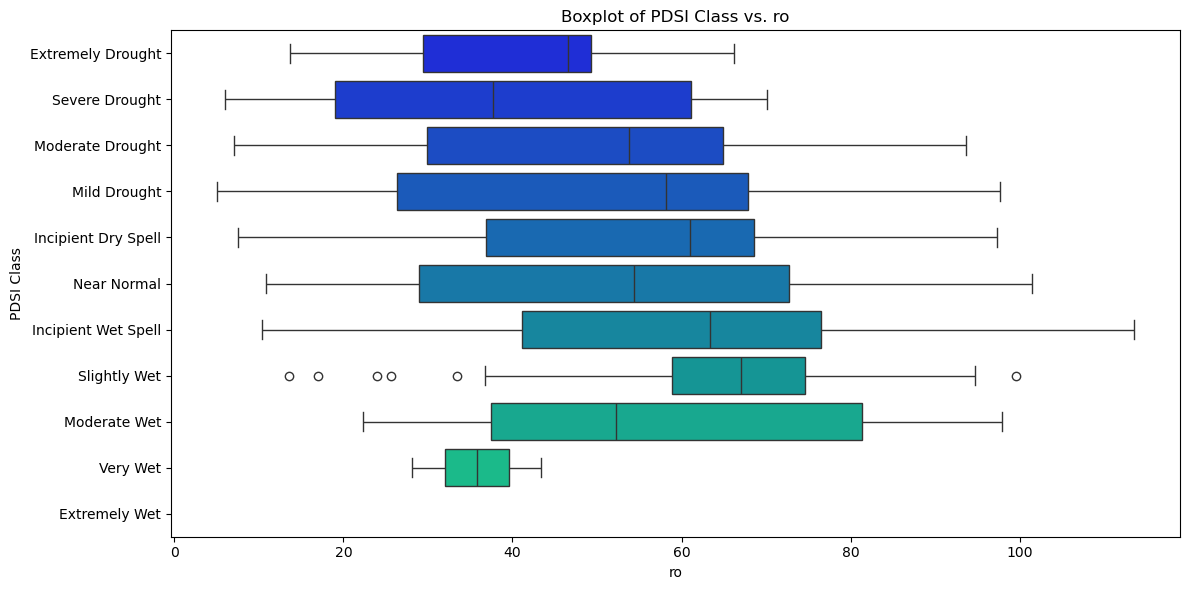

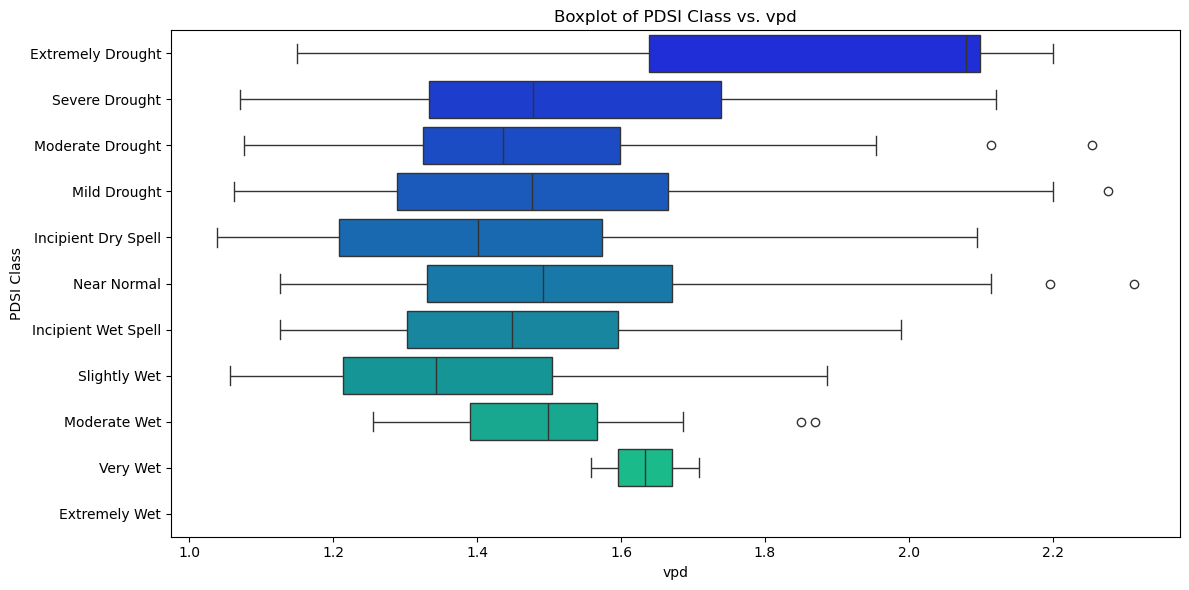

In [29]:

variables = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]

for variable in variables:
    with plt.style.context('default'):
    
        # Create a figure with the specified size and an axis object
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Plot a boxplot using hue set to pdsi_class and disabling the legend
        sns.boxplot(x=variable, y="pdsi_class", data=df_outlier, hue="pdsi_class", palette="winter", ax=ax, dodge=False)
        
        # Set axis labels and title
        ax.set_xlabel(variable)  # Improved label casing for consistency
        ax.set_ylabel('PDSI Class')
        ax.set_title(f'Boxplot of PDSI Class vs. {variable}')
        
        # Optionally adjust the layout if needed
        plt.tight_layout()
        
        # Show the plot
        plt.show()


In [30]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1980-01-01,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280,Mild Drought,3
1,1980-02-01,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518,Mild Drought,3
2,1980-03-01,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892,Moderate Drought,4
3,1980-04-01,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787,Mild Drought,3
4,1980-05-01,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194,Mild Drought,3


## Remove outliers 

In [31]:
# # Drop the non-numeric columns for plotting
# df_outliers =df_time_series.copy
df_outlier = df.drop(columns=['Date'], errors='ignore')
df_outlier.head()

# Ensure columns are numeric
df_outlier = df_outlier.apply(pd.to_numeric, errors='coerce')

# Calculate the first quartile (Q1), third quartile (Q3), and interquartile range (IQR)
Q1 = df_outlier.quantile(0.25)
Q3 = df_outlier.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = (df_outlier < (Q1 - 1.5 * IQR)) | (df_outlier > (Q3 + 1.5 * IQR))

# Drop outliers
df_no_outlier = df_outlier[~outliers.any(axis=1)]

# Show the resulting DataFrame
print(df_no_outlier)


           aet         def         pet          pr         ro       soil  \
0    20.012741  125.743745  145.756779   14.755563  20.012741  18.707876   
1    15.686791  127.846075  143.532888   12.829384  15.686791  15.215722   
2    30.144620  142.985853  173.131090   29.806791  30.144620  13.390553   
3    73.434582   82.037073  155.471958   88.072653  73.434582  22.763092   
4    68.385634   81.221188  149.607218   81.299006  68.385634  29.359973   
..         ...         ...         ...         ...        ...        ...   
523  58.014432   87.674055  145.688745   95.561154  58.014432  51.896659   
524  60.653764   84.010540  144.664400   87.425344  60.653764  53.876407   
525  89.708865   51.829888  141.538549  112.168865  89.708865  60.714309   
526  72.839895   50.475756  123.315741   96.246953  72.839895  64.358316   
527  28.919047  109.794624  138.714730    3.164556  28.919047  38.439979   

           srad       tmmn       tmmx       vap       vpd          vs  \
0    241.85812

In [33]:
# Take the square root of the "precipitation" column
df["pr"] = np.sqrt(df["pr"])

# Take the square root of the "tmmn" column
df["tmmn"] = np.sqrt(df["tmmn"])

# Take the square root of the "tmmx" column
df["tmmx"] = np.sqrt(df["tmmx"])

# Take the square root of the "srad" column
df["srad"] = np.sqrt(df["srad"])

# Take the square root of the "soil" column
df["soil"] = np.sqrt(df["soil"])

# Take the square root of the "vap" column
df["vap"] = np.sqrt(df["vap"])  

# Take the square root of the "vs" column
df["vs"] = np.sqrt(df["vs"])

# Take the square root of the "aet" column
df["aet"] = np.sqrt(df["aet"])

# Take the square root of the "pet" column
df["pet"] = np.sqrt(df["pet"])

# Take the square root of the "ro" column
df["ro"] = np.sqrt(df["ro"])


# Take the square root of the "vpd" column
df["vpd"] = np.sqrt(df["vpd"])

## After Outlier Removals

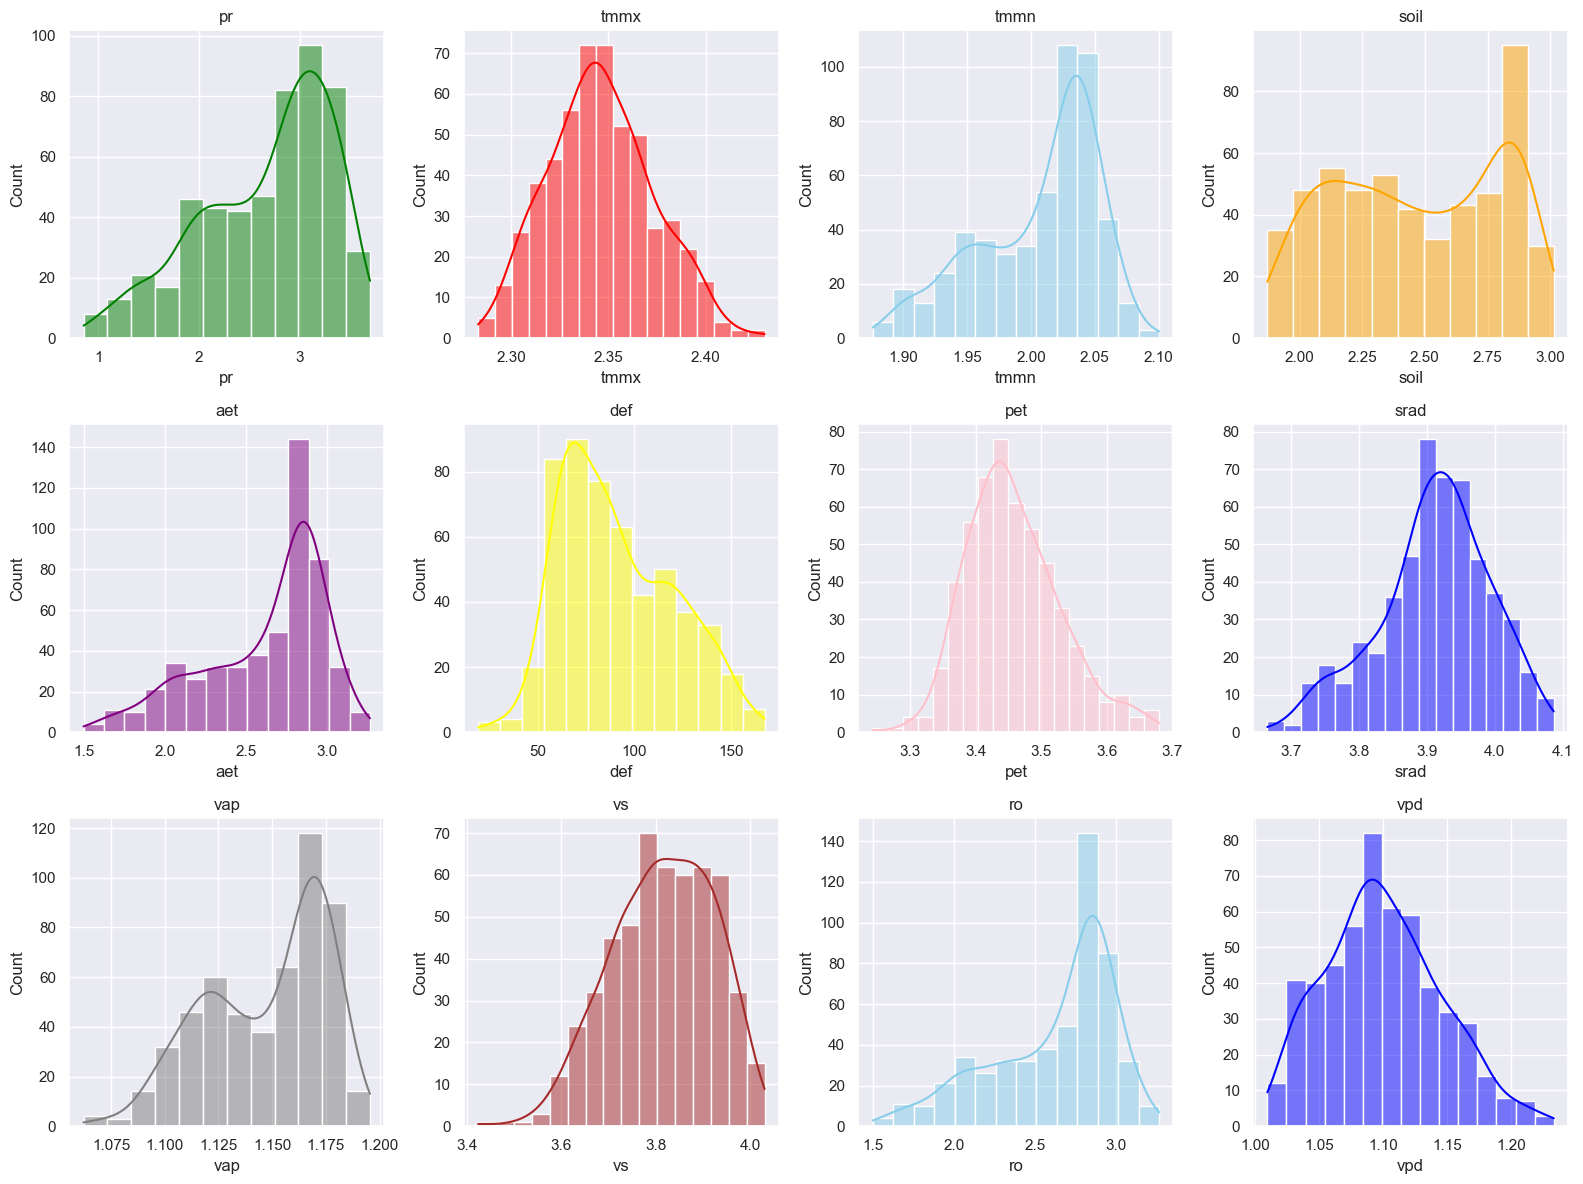

In [34]:
# Set the plot style to darkgrid
sns.set(style="darkgrid")

# Create a 3x4 subplot grid with a specified size
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# Define the variables and colors for the subplots
variables = ["pr", "tmmx", "tmmn", "soil", "aet", "def", "pet", "srad", "vap", "vs", "ro", "vpd"]
colors = ["green", "red", "skyblue", "orange", "purple", "yellow", "pink", "blue", "gray", "brown", "skyblue", "blue"]

# Loop through each column and its index in the variables list
for i, column in enumerate(variables):
    # Calculate row and column index for the subplot
    row = i // 4
    col = i % 4
    
    # Create a histogram plot for the current column, with a kernel density estimate
    # Set the current axis to the appropriate subplot in the grid
    sns.histplot(data=df, x=column, kde=True, ax=axs[row, col], color=colors[i])
    axs[row, col].set_title(column)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [35]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1980-01-01,2.115079,125.743745,3.474619,1.959923,2.115079,2.079726,3.943576,1.955678,2.358165,1.113862,1.128064,3.800468,Mild Drought,3
1,1980-02-01,1.990140,127.846075,3.461289,1.892568,1.990140,1.975027,3.995180,1.998681,2.379572,1.122801,1.160049,3.802926,Mild Drought,3
2,1980-03-01,2.343163,142.985853,3.627386,2.336570,2.343163,1.912932,4.039091,2.036395,2.391180,1.145954,1.165811,3.930057,Moderate Drought,4
3,1980-04-01,2.927353,82.037073,3.531124,3.063446,2.927353,2.184278,4.002970,2.046406,2.370451,1.163317,1.126799,3.809827,Mild Drought,3
4,1980-05-01,2.875684,81.221188,3.497342,3.002765,2.875684,2.327764,3.921163,2.055828,2.359147,1.176154,1.102259,3.774186,Mild Drought,3


## Correlation Matrix

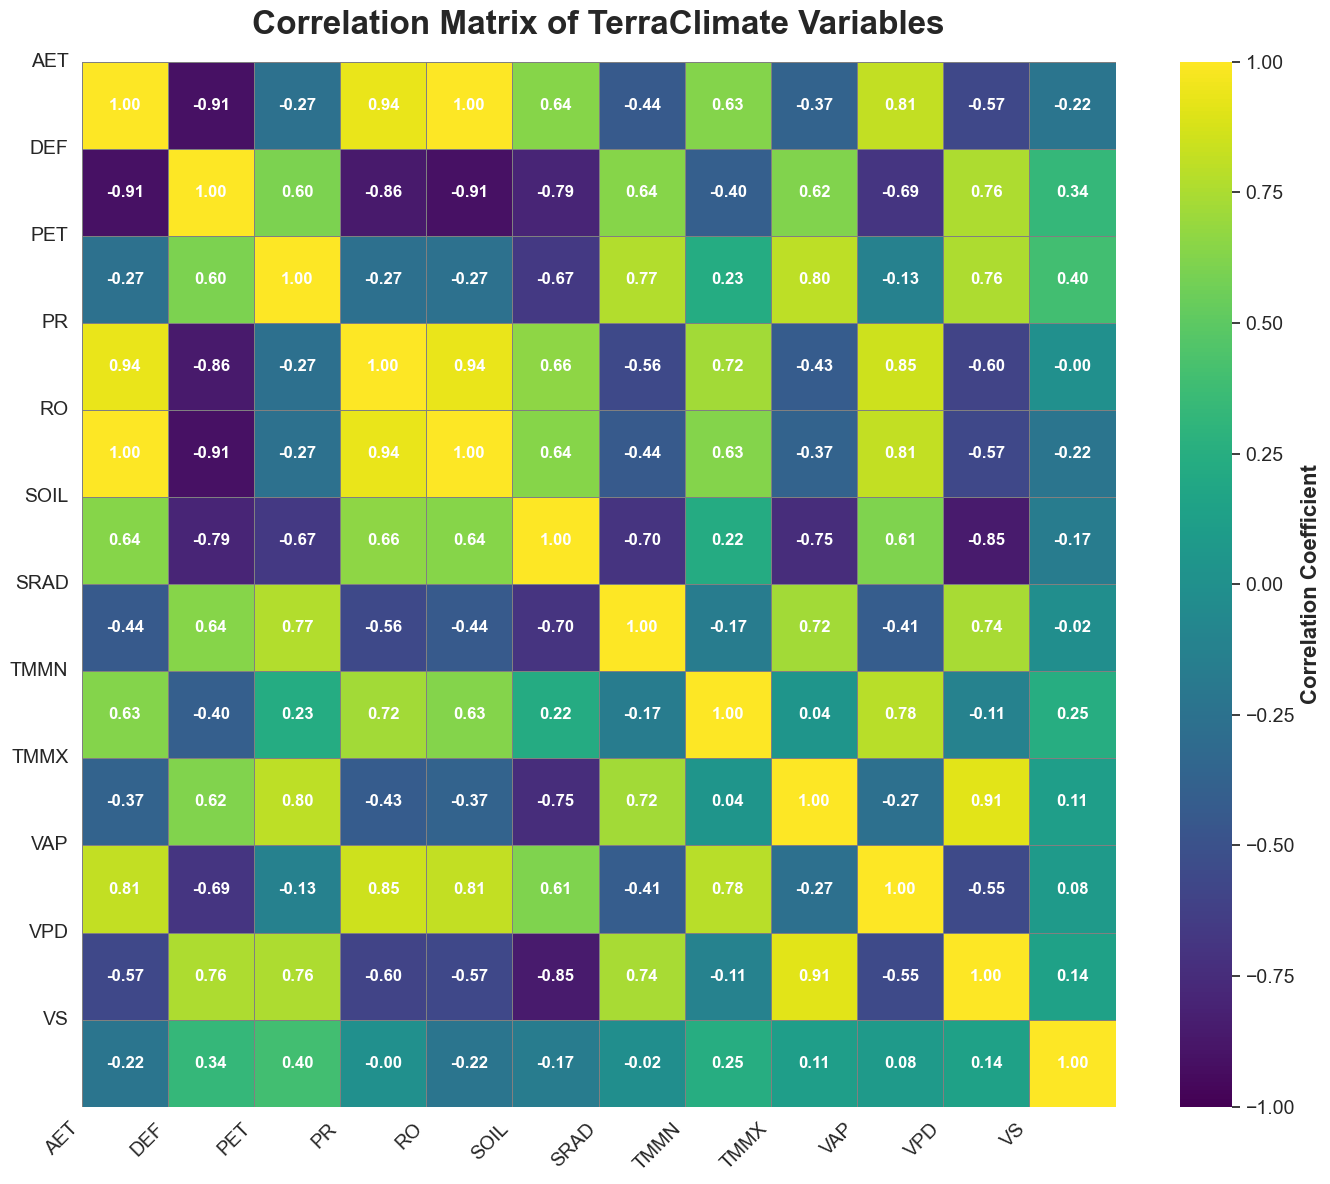

In [36]:
# # Load the data
# df = pd.read_csv('Ethio_terraclimate_Data_scaled.csv')
df_correlation = df.copy()
# Drop non-numeric columns and specific columns to clean the DataFrame
# df_cleaned = df.drop(columns=['.geo', 'system:index', 'ADM0_CODE', 'ADM0_NAME', 'DISP_AREA', 'EXP0_YEAR',
                              # 'STATUS', 'STR0_YEAR', 'Shape_Area', 'Shape_Leng', 'latitude', 'longitude', 'swe'])
df_correlation.head()
# Drop 'Unnamed' columns and 'pdsi' column
# df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_correlation = df_correlation.drop(columns=['pdsi_encoded', 'pdsi_class', 'Date'], errors='ignore')

# # Convert any non-numeric columns to numeric (if applicable) and drop any remaining non-numeric columns
# df_cleaned = df_cleaned.apply(pd.to_numeric, errors='coerce')  # Convert to numeric, set non-convertible to NaN
# df_cleaned = df_cleaned.dropna(axis=1, how='any')  # Drop columns that contain NaN values

# Calculate the correlation matrix
corr_matrix = df_correlation.corr()

# Set up the figure
plt.figure(figsize=(14, 12))
# Enhanced heatmap with improved styling and uppercase variables
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis', vmin=-1, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold', 'color': 'white'}, linewidths=0.5, linecolor='grey')


# Add and format color bar
colorbar = plt.gca().collections[0].colorbar
colorbar.set_label('Correlation Coefficient', fontsize=16, weight='bold')
colorbar.ax.tick_params(labelsize=14)

# Set titles and labels
plt.title('Correlation Matrix of TerraClimate Variables', fontsize=24, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)

# Apply uppercase to x and y ticks
plt.xticks(ticks=range(len(corr_matrix.columns)), labels=[label.upper() for label in corr_matrix.columns], fontsize=14)
plt.yticks(ticks=range(len(corr_matrix.columns)), labels=[label.upper() for label in corr_matrix.columns], fontsize=14)

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout to fit everything
plt.tight_layout()

# Save and show the plot
plt.savefig('Enhanced_Correlation_Matrix_TerraClimate_Uppercase_Improved.png', dpi=300, bbox_inches='tight')
plt.show()



In [37]:
df.head()

,Date,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,1980-01-01,2.115079,125.743745,3.474619,1.959923,2.115079,2.079726,3.943576,1.955678,2.358165,1.113862,1.128064,3.800468,Mild Drought,3
1,1980-02-01,1.990140,127.846075,3.461289,1.892568,1.990140,1.975027,3.995180,1.998681,2.379572,1.122801,1.160049,3.802926,Mild Drought,3
2,1980-03-01,2.343163,142.985853,3.627386,2.336570,2.343163,1.912932,4.039091,2.036395,2.391180,1.145954,1.165811,3.930057,Moderate Drought,4
3,1980-04-01,2.927353,82.037073,3.531124,3.063446,2.927353,2.184278,4.002970,2.046406,2.370451,1.163317,1.126799,3.809827,Mild Drought,3
4,1980-05-01,2.875684,81.221188,3.497342,3.002765,2.875684,2.327764,3.921163,2.055828,2.359147,1.176154,1.102259,3.774186,Mild Drought,3


In [38]:

from sklearn.preprocessing import StandardScaler
df_model = df.copy()

# Prepare features and target
X = df_model.drop(columns=['pdsi_encoded','Date', 'pdsi_class'])
y = df_model['pdsi_encoded']

# Initialize the StandardScaler
scaler = StandardScaler()
# Fit and transform the data (standardize)
X_standardized = scaler.fit_transform(X)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

Training set size: 422
Testing set size: 106


In [39]:
print(df_outlier['pdsi_class'].unique())  # Check unique values in the original pdsi_class column


[nan]


In [40]:
df_outlier.head()

,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded
0,20.012741,125.743745,145.756779,14.755563,20.012741,18.707876,241.858129,14.628137,30.924068,1.539310,1.619330,208.616280,NaN,3
1,15.686791,127.846075,143.532888,12.829384,15.686791,15.215722,254.768299,15.957836,32.062363,1.589322,1.810947,209.156518,NaN,3
2,30.144620,142.985853,173.131090,29.806791,30.144620,13.390553,266.154887,17.196825,32.692545,1.724521,1.847195,238.558892,NaN,4
3,73.434582,82.037073,155.471958,88.072653,73.434582,22.763092,256.761257,17.537496,31.573567,1.831441,1.612078,210.678787,NaN,3
4,68.385634,81.221188,149.607218,81.299006,68.385634,29.359973,236.406485,17.862684,30.975638,1.913622,1.476164,202.905194,NaN,3


In [41]:
df.dtypes

Date              object
aet              float64
def              float64
pet              float64
pr               float64
ro               float64
soil             float64
srad             float64
tmmn             float64
tmmx             float64
vap              float64
vpd              float64
vs               float64
pdsi_class      category
pdsi_encoded       int32
dtype: object

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


df_lag = df.copy()
# Assuming 'df' contains the PDSI values and other features
df_lag['Date'] = pd.to_datetime(df_lag['Date'])
df_lag.set_index('Date', inplace=True)

# Create lag features for lead times of 1, 3, 6, and 12 months
df_lag['pdsi_1month'] = df_lag['pdsi_encoded'].shift(-1)
df_lag['pdsi_3month'] = df_lag['pdsi_encoded'].shift(-3)
df_lag['pdsi_6month'] = df_lag['pdsi_encoded'].shift(-6)
df_lag['pdsi_12month'] = df_lag['pdsi_encoded'].shift(-12)

# Drop rows with NaN values (due to shifting)
df_lag.dropna(inplace=True)


In [49]:
df_lag.head()

,aet,def,pet,pr,ro,soil,srad,tmmn,tmmx,vap,vpd,vs,pdsi_class,pdsi_encoded,pdsi_1month,pdsi_3month,pdsi_6month,pdsi_12month
Date,,,,,,,,,,,,,,,,,,
1980-01-01,2.115079,125.743745,3.474619,1.959923,2.115079,2.079726,3.943576,1.955678,2.358165,1.113862,1.128064,3.800468,Mild Drought,3,3.0,3.0,4.0,4.0
1980-02-01,1.990140,127.846075,3.461289,1.892568,1.990140,1.975027,3.995180,1.998681,2.379572,1.122801,1.160049,3.802926,Mild Drought,3,4.0,3.0,3.0,7.0
1980-03-01,2.343163,142.985853,3.627386,2.336570,2.343163,1.912932,4.039091,2.036395,2.391180,1.145954,1.165811,3.930057,Moderate Drought,4,3.0,3.0,4.0,3.0
1980-04-01,2.927353,82.037073,3.531124,3.063446,2.927353,2.184278,4.002970,2.046406,2.370451,1.163317,1.126799,3.809827,Mild Drought,3,3.0,4.0,4.0,6.0
1980-05-01,2.875684,81.221188,3.497342,3.002765,2.875684,2.327764,3.921163,2.055828,2.359147,1.176154,1.102259,3.774186,Mild Drought,3,3.0,3.0,4.0,6.0


In [50]:
# Define features and target for each lead time
features = ['aet', 'def', 'pet', 'pr', 'ro', 'soil', 'srad', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']

# Train-Test Split
X = df_lag[features]

# For 1-month lead time
y_1month = df_lag['pdsi_1month']
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y_1month, test_size=0.2, random_state=42)

# For 3-month lead time
y_3month = df_lag['pdsi_3month']
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y_3month, test_size=0.2, random_state=42)

# For 6-month lead time
y_6month = df_lag['pdsi_6month']
X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X, y_6month, test_size=0.2, random_state=42)

# For 12-month lead time
y_12month = df_lag['pdsi_12month']
X_train_12, X_test_12, y_train_12, y_test_12 = train_test_split(X, y_12month, test_size=0.2, random_state=42)

# Train Random Forest Regressor for each lead time
rf_1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_1.fit(X_train_1, y_train_1)
y_pred_1 = rf_1.predict(X_test_1)

rf_3 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_3.fit(X_train_3, y_train_3)
y_pred_3 = rf_3.predict(X_test_3)

rf_6 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_6.fit(X_train_6, y_train_6)
y_pred_6 = rf_6.predict(X_test_6)

rf_12 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_12.fit(X_train_12, y_train_12)
y_pred_12 = rf_12.predict(X_test_12)


In [45]:
# Evaluate models using Mean Squared Error (MSE)
mse_1month = mean_squared_error(y_test_1, y_pred_1)
mse_3month = mean_squared_error(y_test_3, y_pred_3)
mse_6month = mean_squared_error(y_test_6, y_pred_6)
mse_12month = mean_squared_error(y_test_12, y_pred_12)

print(f'MSE for 1-month lead time: {mse_1month}')
print(f'MSE for 3-month lead time: {mse_3month}')
print(f'MSE for 6-month lead time: {mse_6month}')
print(f'MSE for 12-month lead time: {mse_12month}')


MSE for 1-month lead time: 4.779031730769231
MSE for 3-month lead time: 5.071753846153846
MSE for 6-month lead time: 5.5609375
MSE for 12-month lead time: 5.817138461538462


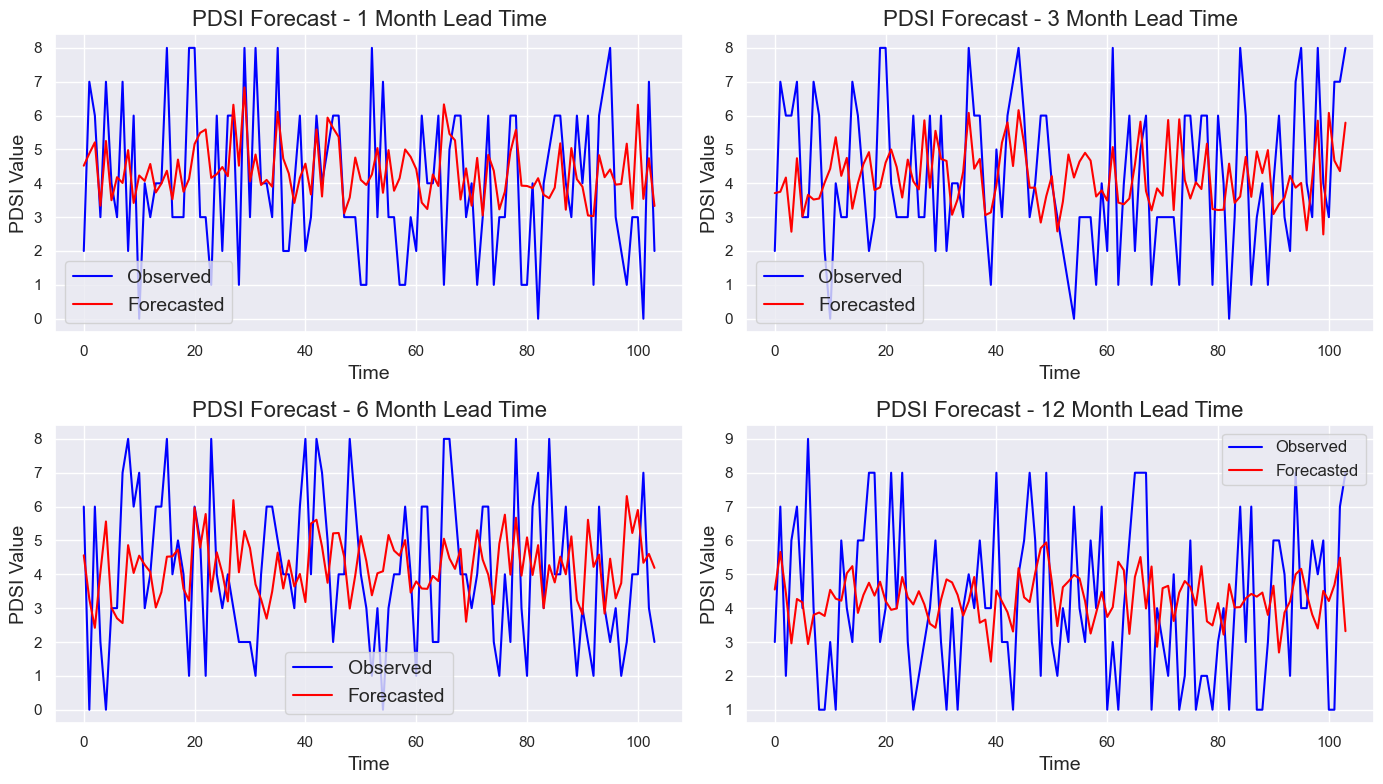

In [46]:
# Plot Observed vs Forecasted PDSI for different lead times
plt.figure(figsize=(14, 8))

# 1-month lead time
plt.subplot(2, 2, 1)
plt.plot(y_test_1.values, label='Observed', color='blue')
plt.plot(y_pred_1, label='Forecasted', color='red')
plt.title('PDSI Forecast - 1 Month Lead Time',  fontsize=16)
plt.legend(fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PDSI Value', fontsize=14)

# 3-month lead time
plt.subplot(2, 2, 2)
plt.plot(y_test_3.values, label='Observed', color='blue')
plt.plot(y_pred_3, label='Forecasted', color='red')
plt.title('PDSI Forecast - 3 Month Lead Time',  fontsize=16)
plt.legend(fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PDSI Value', fontsize=14)

# 6-month lead time
plt.subplot(2, 2, 3)
plt.plot(y_test_6.values, label='Observed', color='blue')
plt.plot(y_pred_6, label='Forecasted', color='red')
plt.title('PDSI Forecast - 6 Month Lead Time',  fontsize=16)
plt.legend(fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.ylabel('PDSI Value', fontsize=14)

# 12-month lead time
plt.subplot(2, 2, 4)
plt.plot(y_test_12.values, label='Observed', color='blue')
plt.plot(y_pred_12, label='Forecasted', color='red')
plt.title('PDSI Forecast - 12 Month Lead Time',  fontsize=16)
plt.legend(fontsize=14)



# Add legend with a larger font size
plt.legend(fontsize=12)

# Optionally, you can also increase the font size of the X and Y labels
plt.xlabel('Time', fontsize=14)
plt.ylabel('PDSI Value', fontsize=14)
plt.tight_layout()
# Save the figure
plt.savefig('PDSI_Forcast.png', dpi=300, bbox_inches='tight')
plt.show()


In [51]:
df_model = df.copy()

# Prepare features and target
X = df_model.drop(columns=['pdsi_encoded','Date', 'pdsi_class'])
y = df_model['pdsi_encoded']

# Initialize the StandardScaler
scaler = StandardScaler()
# Fit and transform the data (standardize)
X_standardized = scaler.fit_transform(X)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

Training set size: 422
Testing set size: 106


In [45]:
from sklearn.neighbors import KNeighborsClassifier

# create a KNN classifier and fit it to the training data
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

# calculate the accuracy score of the KNN classifier on the test data
knn_score = knn.score(x_test, y_test)
print("KNN Accuracy:", knn_score)

KNN Accuracy: 0.21153846153846154


In [52]:
x_train.shape

(422, 12)

In [53]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

In [54]:
# Manually duplicate the smallest classes
df_minority = df[df['pdsi_encoded'].isin([9, 0, 5])]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=10, random_state=42)  # Upsample to 10 samples

# Combine the upsampled minority with the rest of the data
df_balanced = pd.concat([df[df['pdsi_encoded'].isin([9, 0, 5]) == False], df_minority_upsampled])

# Separate features and target
X_balanced = df_balanced.drop(columns=['Date', 'pdsi_class', 'pdsi_encoded'])
y_balanced = df_balanced['pdsi_encoded']

# Apply SMOTE on the remaining data
smote = SMOTE(random_state=42, k_neighbors=2)  # Set k_neighbors to a smaller number
X_resampled, y_resampled = smote.fit_resample(X_balanced, y_balanced)

# Proceed with the resampled data for machine learning


In [57]:
# Example: Using a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split the resampled data into training and test sets
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train a Random Forest classifier
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = clf_rf.predict(X_test_resampled)

# Evaluate the model
print(classification_report(y_test_resampled, y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       0.52      0.55      0.54        20
           2       0.52      0.71      0.60        17
           3       0.25      0.17      0.20        24
           4       0.36      0.31      0.33        26
           5       0.95      0.95      0.95        21
           6       0.30      0.15      0.20        20
           7       0.68      0.82      0.74        28
           8       0.56      0.74      0.64        19

    accuracy                           0.60       198
   macro avg       0.56      0.60      0.57       198
weighted avg       0.56      0.60      0.57       198



In [58]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with class weights
clf_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf_rf.fit(x_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [59]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

# Manually upsample classes with very few samples (like 9, 0, 5)
df_minority = df[df['pdsi_encoded'].isin([9, 0, 5])]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=10, random_state=42)

# Combine the upsampled minority with the rest of the data
df_balanced = pd.concat([df[df['pdsi_encoded'].isin([9, 0, 5]) == False], df_minority_upsampled])

# Separate features and target
X_balanced = df_balanced.drop(columns=['Date', 'pdsi_class', 'pdsi_encoded'])
y_balanced = df_balanced['pdsi_encoded']

# Apply SMOTE on the remaining data
smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X_balanced, y_balanced)


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Split the resampled data into training and test sets
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train each classifier and evaluate
for name, clf in classifiers.items():
    clf.fit(X_train_resampled, y_train_resampled)
    y_pred = clf.predict(X_test_resampled)
    
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test_resampled, y_pred):.4f}")
    print(classification_report(y_test_resampled, y_pred))
    print("-" * 40)


C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results:
Accuracy: 0.3586
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        23
           1       0.00      0.00      0.00        20
           2       0.31      0.47      0.37        17
           3       0.23      0.12      0.16        24
           4       0.00      0.00      0.00        26
           5       0.48      0.71      0.58        21
           6       0.20      0.10      0.13        20
           7       0.32      0.39      0.35        28
           8       0.20      0.47      0.29        19

    accuracy                           0.36       198
   macro avg       0.26      0.36      0.29       198
weighted avg       0.26      0.36      0.29       198

----------------------------------------
Random Forest Results:
Accuracy: 0.5960
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       0.52      0.55      0.54        20
     

C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Gradient Boosting Results:
Accuracy: 0.5657
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        23
           1       0.39      0.55      0.46        20
           2       0.53      0.59      0.56        17
           3       0.27      0.29      0.28        24
           4       0.38      0.31      0.34        26
           5       1.00      0.86      0.92        21
           6       0.36      0.25      0.29        20
           7       0.73      0.68      0.70        28
           8       0.52      0.58      0.55        19

    accuracy                           0.57       198
   macro avg       0.57      0.57      0.56       198
weighted avg       0.57      0.57      0.56       198

----------------------------------------


In [61]:
from sklearn.model_selection import cross_val_score

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_resampled, y_resampled, cv=5)
    print(f"{name} Cross-Validation Accuracy: {scores.mean():.4f}")


C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\LEBELA TADELE MELESE\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html

Logistic Regression Cross-Validation Accuracy: 0.3424
Random Forest Cross-Validation Accuracy: 0.6222
SVM Cross-Validation Accuracy: 0.2071
KNN Cross-Validation Accuracy: 0.4626
Gradient Boosting Cross-Validation Accuracy: 0.5838


In [53]:
import pandas as pd


# Convert 'Date' to datetime and set it as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


# Model Training

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Import XGBoost if available
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

# Split the resampled data into training and test sets
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Add XGBoost if it's available
if xgboost_available:
    classifiers["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train each classifier and evaluate
for name, clf in classifiers.items():
    clf.fit(X_train_resampled, y_train_resampled)
    y_pred = clf.predict(X_test_resampled)
    
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test_resampled, y_pred):.4f}")
    print(classification_report(y_test_resampled, y_pred))
    print("-" * 40)


Logistic Regression Results:
Accuracy: 0.3586
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        23
           1       0.00      0.00      0.00        20
           2       0.31      0.47      0.37        17
           3       0.23      0.12      0.16        24
           4       0.00      0.00      0.00        26
           5       0.48      0.71      0.58        21
           6       0.20      0.10      0.13        20
           7       0.32      0.39      0.35        28
           8       0.20      0.47      0.29        19

    accuracy                           0.36       198
   macro avg       0.26      0.36      0.29       198
weighted avg       0.26      0.36      0.29       198

----------------------------------------
Random Forest Results:
Accuracy: 0.5960
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        23
           1       0.52      0.55      0.54        20
     

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
rf_model = RandomForestClassifier()

# Define the hyperparameters grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

# Fit the model with the best parameters
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)



Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Import XGBoost if available
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False

# Split the resampled data into training and test sets
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),  # Comma added here
    "Random Forest": RandomForestClassifier(max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=300, random_state=42),  # Comma added here
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}


# Add XGBoost if it's available
if xgboost_available:
    classifiers["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train each classifier and evaluate
for name, clf in classifiers.items():
    clf.fit(X_train_resampled, y_train_resampled)
    y_pred = clf.predict(X_test_resampled)
    
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test_resampled, y_pred):.4f}")
    print(classification_report(y_test_resampled, y_pred))
    print("-" * 40)


Logistic Regression Results:
Accuracy: 0.3586
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        23
           1       0.00      0.00      0.00        20
           2       0.31      0.47      0.37        17
           3       0.23      0.12      0.16        24
           4       0.00      0.00      0.00        26
           5       0.48      0.71      0.58        21
           6       0.20      0.10      0.13        20
           7       0.32      0.39      0.35        28
           8       0.20      0.47      0.29        19

    accuracy                           0.36       198
   macro avg       0.26      0.36      0.29       198
weighted avg       0.26      0.36      0.29       198

----------------------------------------
Decision Tree Results:
Accuracy: 0.5303
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        23
           1       0.38      0.45      0.41        20
     

# Hyper Parameter Tuning

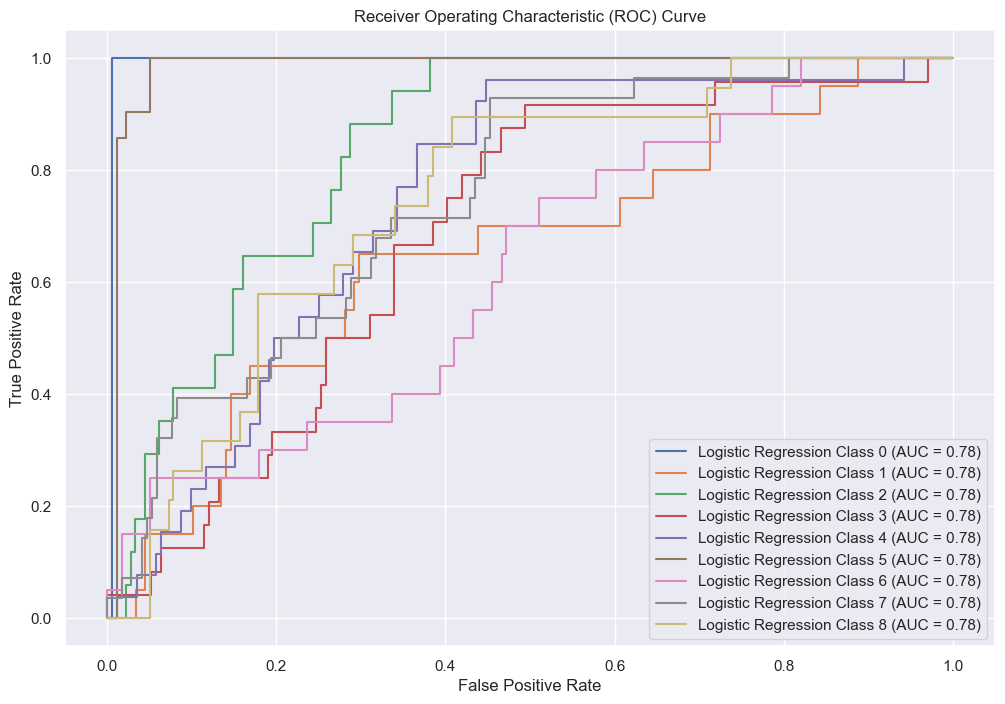

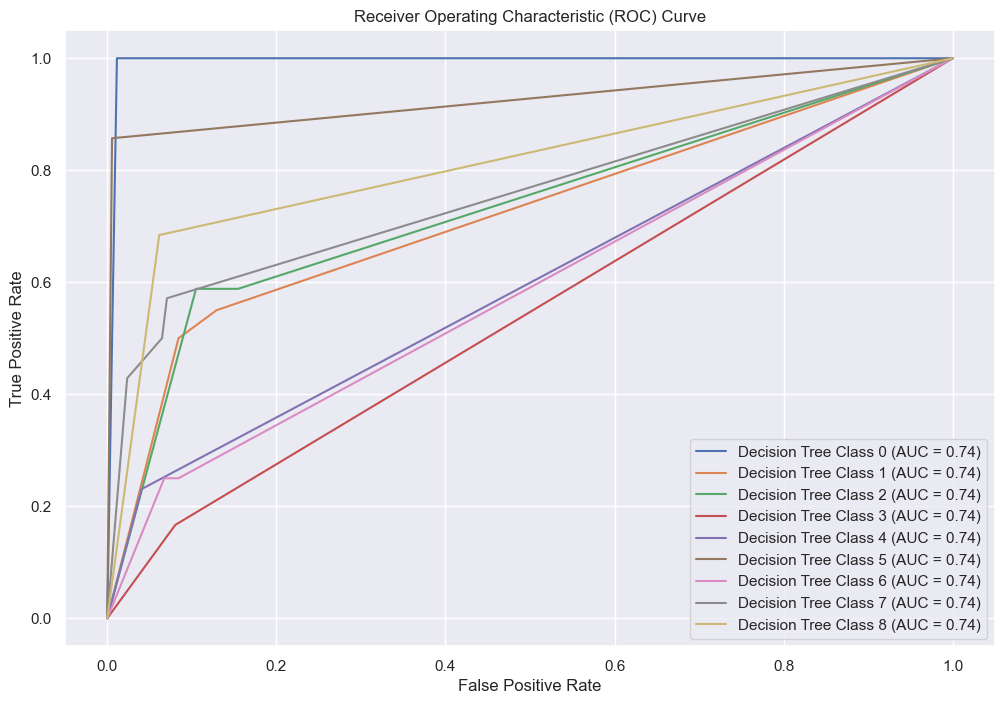

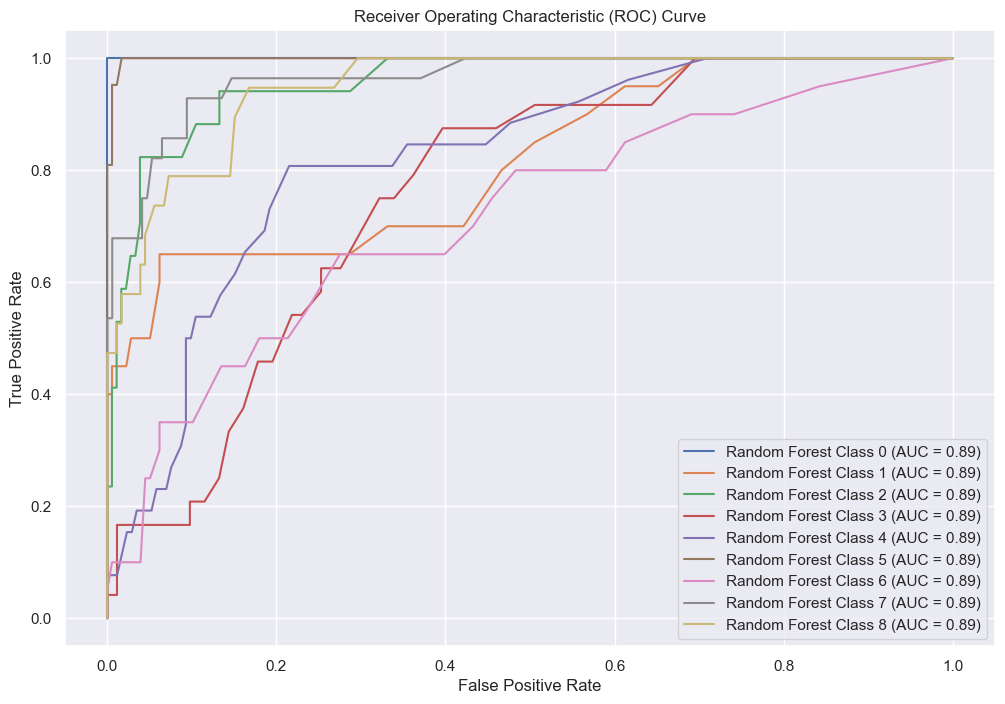

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Define parameter grids for each classifier
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },
    "Naive Bayes": {},  # Naive Bayes has no hyperparameters to tune
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

# Add parameter grid for XGBoost if it's available
if xgboost_available:
    param_grids["XGBoost"] = {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    }

# Initialize lists to store results
results = []
roc_auc_results = {}

# Perform hyperparameter tuning and evaluation
for name, clf in classifiers.items():
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_clf.predict(X_test_resampled)
    y_prob = best_clf.predict_proba(X_test_resampled)  # Probabilities for ROC AUC

    # Calculate accuracy and ROC AUC
    accuracy = accuracy_score(y_test_resampled, y_pred)
    
    # For multi-class ROC AUC
    if len(np.unique(y_test_resampled)) > 2:
        roc_auc = roc_auc_score(y_test_resampled, y_prob, multi_class='ovr')
    else:
        roc_auc = roc_auc_score(y_test_resampled, y_prob[:, 1])
    
    fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, 1]) if len(np.unique(y_test_resampled)) <= 2 else (None, None, None)

    results.append((name, accuracy, roc_auc))

    # Plot ROC curve
    plt.figure(figsize=(12, 8))
    if fpr is not None and tpr is not None:
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    else:
        for i in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, i], pos_label=i)
            plt.plot(fpr, tpr, label=f'{name} Class {i} (AUC = {roc_auc:.2f})')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Print results
for name, accuracy, roc_auc in results:
    print(f"{name} Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 40)

In [ ]:
# Define classifiers with SVC including probability=True
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability estimates
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Define parameter grids for each classifier
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },
    "Naive Bayes": {},  # Naive Bayes has no hyperparameters to tune
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

# Initialize lists to store results
results = []
roc_auc_results = {}

# Perform hyperparameter tuning and evaluation
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, (name, clf) in enumerate(classifiers.items()):
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_clf.predict(X_test_resampled)
    y_prob = best_clf.predict_proba(X_test_resampled)  # Probabilities for ROC AUC

    # Calculate accuracy and ROC AUC
    accuracy = accuracy_score(y_test_resampled, y_pred)
    
    if len(np.unique(y_test_resampled)) > 2:
        roc_auc = roc_auc_score(y_test_resampled, y_prob, multi_class='ovr')
        for j in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, j], pos_label=j)
            axes[i].plot(fpr, tpr, label=f'{name} Class {j}')
    else:
        roc_auc = roc_auc_score(y_test_resampled, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, 1])
        axes[i].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    axes[i].set_title(name)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# Print results
for name, accuracy, roc_auc in results:
    print(f"{name} Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 40)


C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


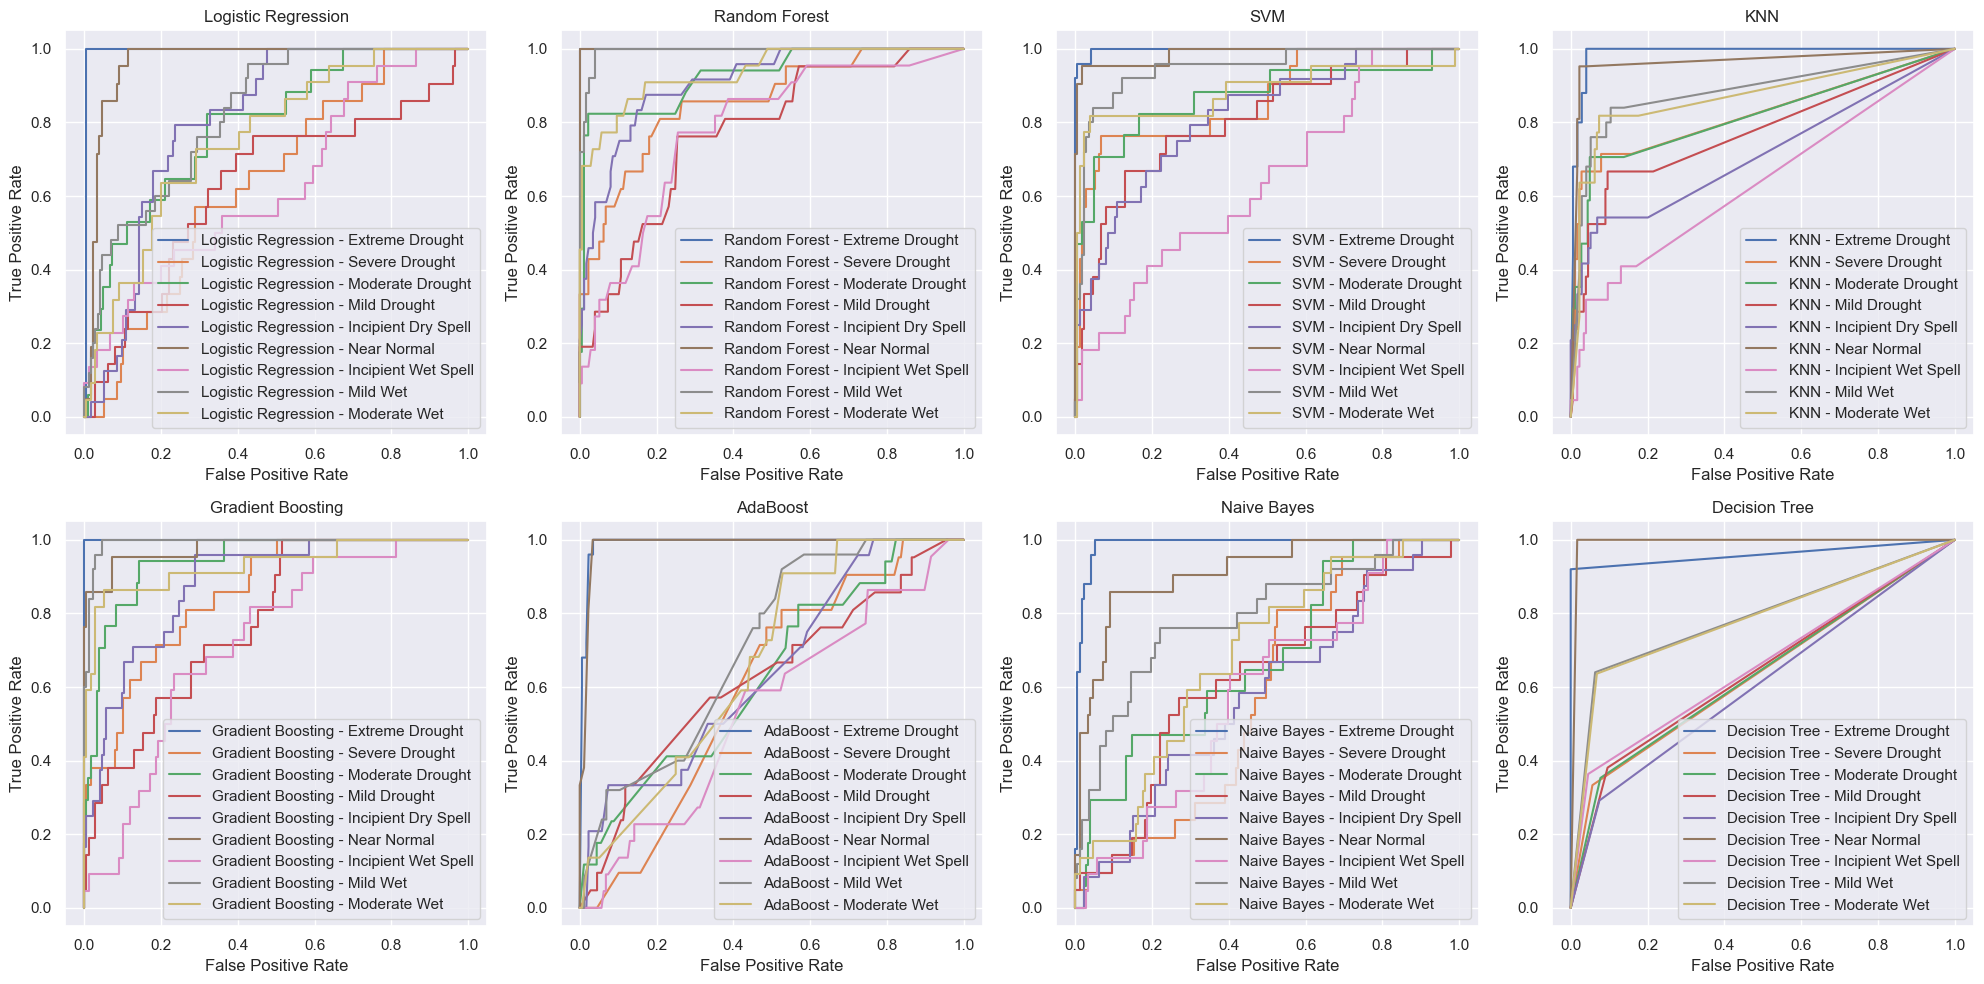

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Define classifiers with SVC including probability=True
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability estimates
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Define parameter grids for each classifier
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },
    "Naive Bayes": {},  # Naive Bayes has no hyperparameters to tune
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

# Define class names corresponding to drought/wetness categories
class_names = [
    'Extreme Drought', 'Severe Drought', 'Moderate Drought',
    'Mild Drought', 'Incipient Dry Spell', 'Near Normal',
    'Incipient Wet Spell', 'Mild Wet', 'Moderate Wet', 'Severe Wet'
]

# Initialize lists to store results
results = []
roc_auc_results = {}

# Perform hyperparameter tuning and evaluation
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Adjust to plot 8 figures in a 2x4 grid
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, (name, clf) in enumerate(classifiers.items()):
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_clf.predict(X_test_resampled)
    y_prob = best_clf.predict_proba(X_test_resampled)  # Probabilities for ROC AUC

    # Calculate accuracy and ROC AUC
    accuracy = accuracy_score(y_test_resampled, y_pred)
    
    if len(np.unique(y_test_resampled)) > 2:
        roc_auc = roc_auc_score(y_test_resampled, y_prob, multi_class='ovr')
        for j in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, j], pos_label=j)
            axes[i].plot(fpr, tpr, label=f'{name} - {class_names[j]}')
    else:
        roc_auc = roc_auc_score(y_test_resampled, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, 1])
        axes[i].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    axes[i].set_title(name)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].grid(True)
    axes[i].legend(loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# Print results
for name, accuracy, roc_auc in results:
    print(f"{name} Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 40)


C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


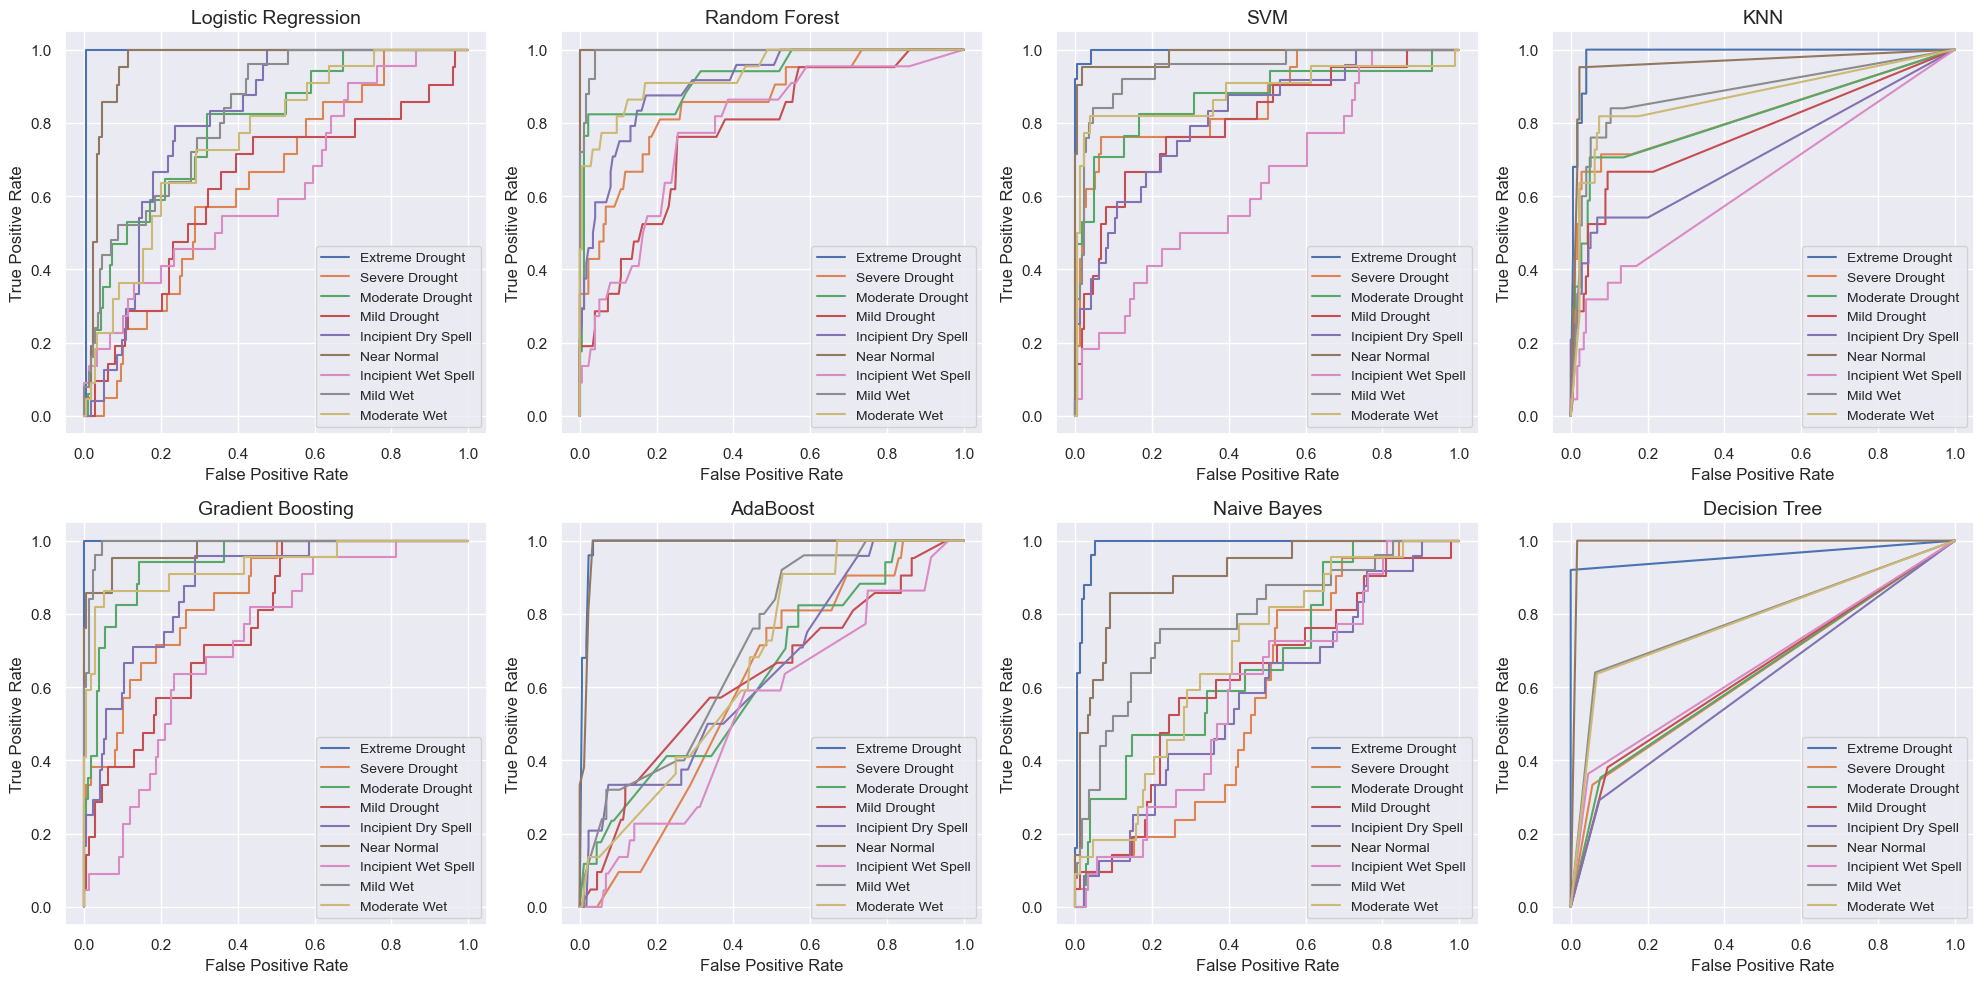

In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Define classifiers with SVC including probability=True
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability estimates
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Define parameter grids for each classifier
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },
    "Naive Bayes": {},  # Naive Bayes has no hyperparameters to tune
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

# Define class names corresponding to drought/wetness categories
class_names = [
    'Extreme Drought', 'Severe Drought', 'Moderate Drought',
    'Mild Drought', 'Incipient Dry Spell', 'Near Normal',
    'Incipient Wet Spell', 'Mild Wet', 'Moderate Wet', 'Severe Wet'
]

# Initialize lists to store results
results = []
roc_auc_results = {}

# Perform hyperparameter tuning and evaluation
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Adjust to plot 8 figures in a 2x4 grid
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, (name, clf) in enumerate(classifiers.items()):
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_clf.predict(X_test_resampled)
    y_prob = best_clf.predict_proba(X_test_resampled)  # Probabilities for ROC AUC

    # Calculate accuracy and ROC AUC
    accuracy = accuracy_score(y_test_resampled, y_pred)
    
    if len(np.unique(y_test_resampled)) > 2:
        roc_auc = roc_auc_score(y_test_resampled, y_prob, multi_class='ovr')
        for j in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, j], pos_label=j)
            axes[i].plot(fpr, tpr, label=f'{class_names[j]}')
    else:
        roc_auc = roc_auc_score(y_test_resampled, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, 1])
        axes[i].plot(fpr, tpr, label=f'{class_names[1]} (AUC = {roc_auc:.2f})')

    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('False Positive Rate', fontsize=14)
    axes[i].set_ylabel('True Positive Rate', fontsize=14)
    axes[i].grid(True)
    axes[i].legend(loc='lower right', fontsize=14)

# Adjust layout and save plot
plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=300)  # Save the figure as an image file
plt.show()

# Print results
for name, accuracy, roc_auc in results:
    print(f"{name} Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 40)


C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


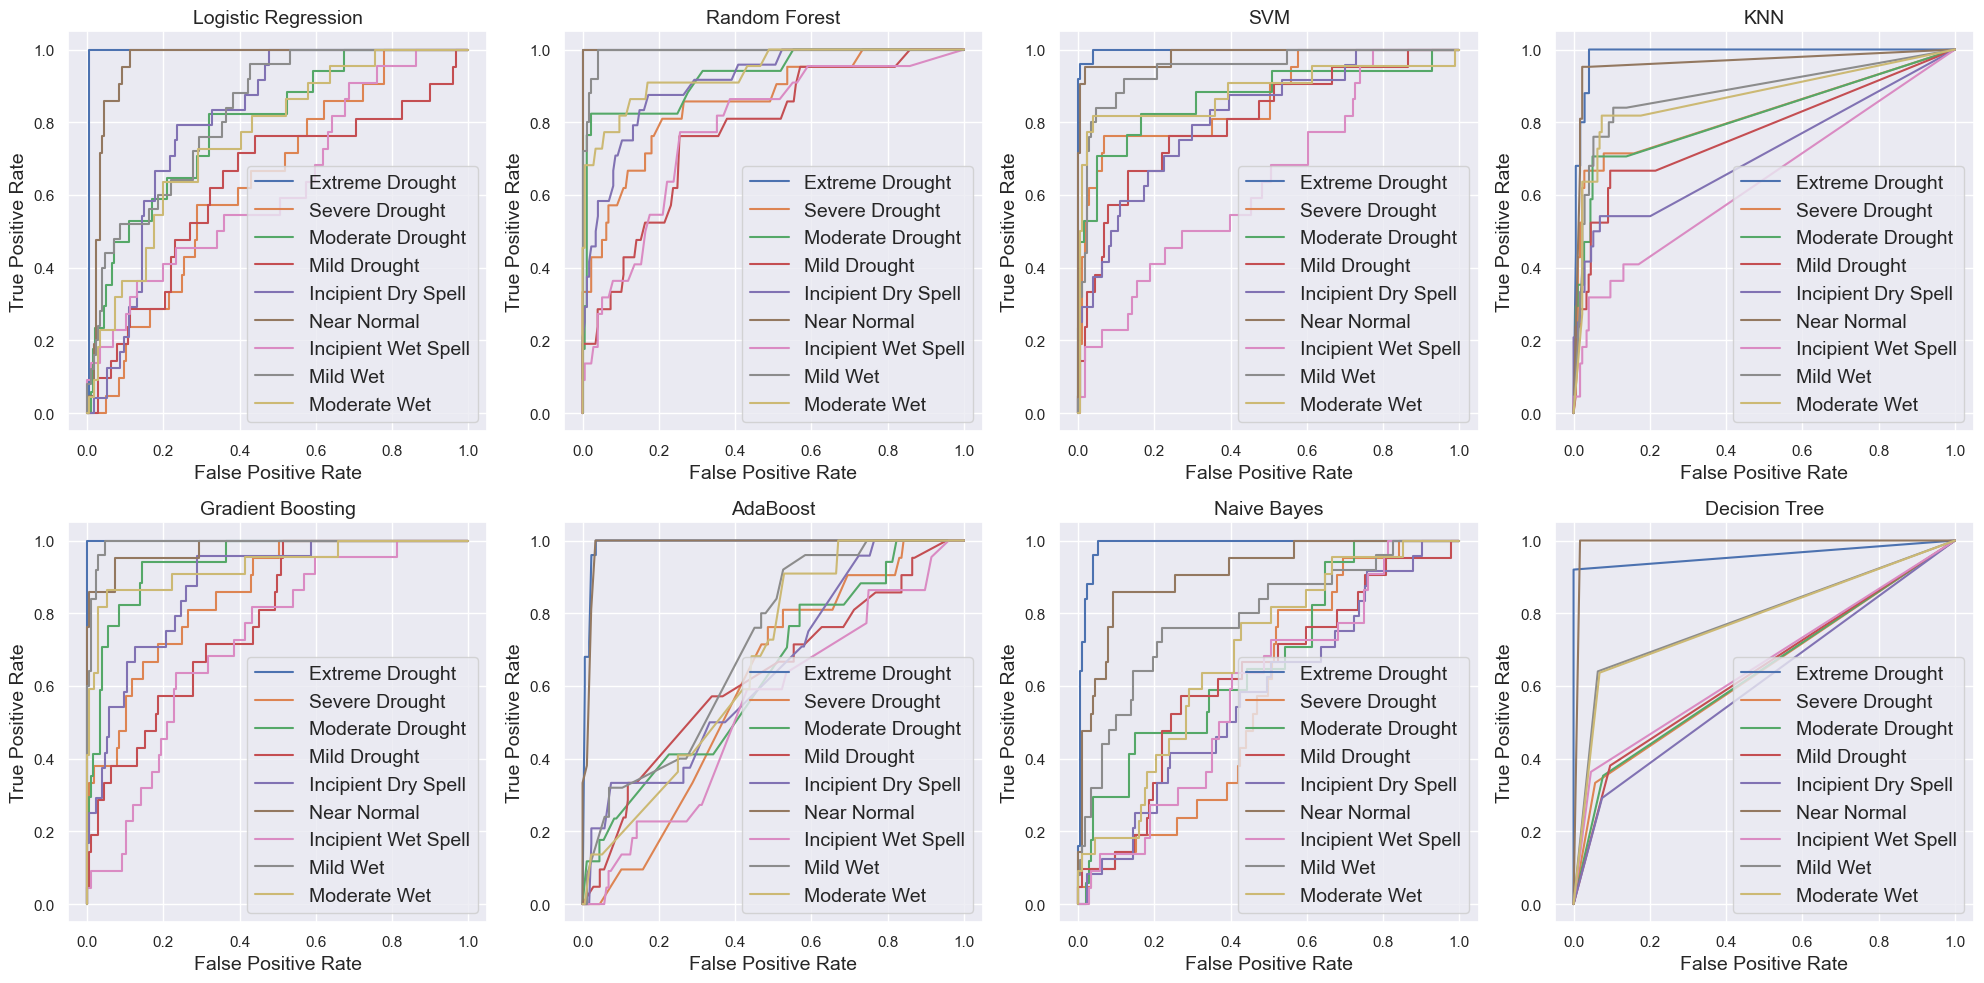

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Define classifiers with SVC including probability=True
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability estimates
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Define parameter grids for each classifier
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },
    "Naive Bayes": {},  # Naive Bayes has no hyperparameters to tune
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    }
}

# Define class names corresponding to drought/wetness categories
class_names = [
    'Extreme Drought', 'Severe Drought', 'Moderate Drought',
    'Mild Drought', 'Incipient Dry Spell', 'Near Normal',
    'Incipient Wet Spell', 'Mild Wet', 'Moderate Wet', 'Severe Wet'
]

# Initialize lists to store results
results = []
roc_auc_results = {}

# Perform hyperparameter tuning and evaluation
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # Adjust to plot 8 figures in a 2x4 grid
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, (name, clf) in enumerate(classifiers.items()):
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_clf.predict(X_test_resampled)
    y_prob = best_clf.predict_proba(X_test_resampled)  # Probabilities for ROC AUC

    # Calculate accuracy and ROC AUC
    accuracy = accuracy_score(y_test_resampled, y_pred)
    
    if len(np.unique(y_test_resampled)) > 2:
        roc_auc = roc_auc_score(y_test_resampled, y_prob, multi_class='ovr')
        for j in range(y_prob.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, j], pos_label=j)
            axes[i].plot(fpr, tpr, label=f'{class_names[j]}')
    else:
        roc_auc = roc_auc_score(y_test_resampled, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test_resampled, y_prob[:, 1])
        axes[i].plot(fpr, tpr, label=f'{class_names[1]} (AUC = {roc_auc:.2f})')

    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('False Positive Rate', fontsize=14)
    axes[i].set_ylabel('True Positive Rate', fontsize=14)
    axes[i].grid(True)
    axes[i].legend(loc='lower right', fontsize=14)

# Adjust layout and save plot
plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=300)  # Save the figure as an image file
plt.show()

# Print results
for name, accuracy, roc_auc in results:
    print(f"{name} Results:")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 40)


C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


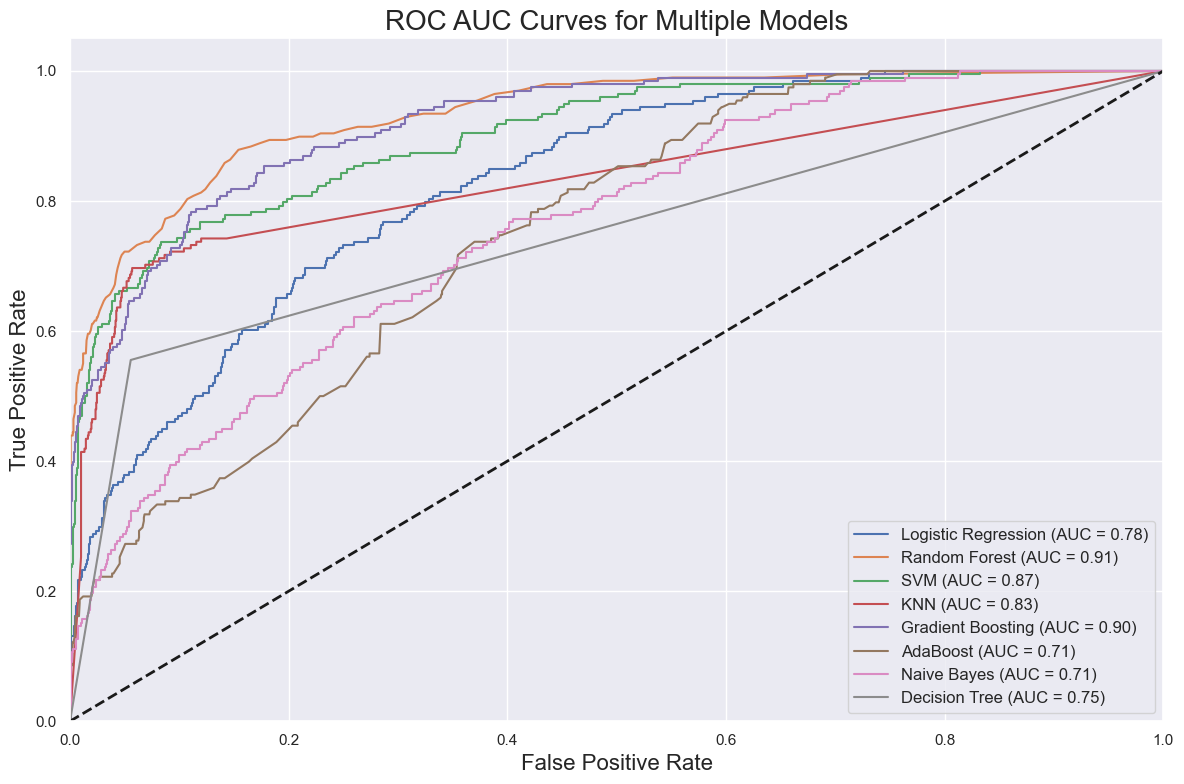

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Define class names
class_names = np.unique(y_test_resampled)

# Initialize the plot
plt.figure(figsize=(12, 8))

# Binarize the output for multiclass ROC AUC
y_test_binarized = label_binarize(y_test_resampled, classes=class_names)

# Loop through classifiers and plot ROC AUC for each model (not per class)
for name, clf in classifiers.items():
    grid_search = GridSearchCV(clf, param_grids.get(name, {}), cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_clf = grid_search.best_estimator_
    
    # Predict probabilities on the test set
    y_prob = best_clf.predict_proba(X_test_resampled)
    
    # Compute ROC AUC for the whole model (macro-average)
    roc_auc = roc_auc_score(y_test_binarized, y_prob, average="macro", multi_class="ovr")
    
    # Compute ROC curve and plot for the overall model
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_prob.ravel())
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot configurations
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC AUC Curves for Multiple Models', fontsize=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)

# Save and display plot
plt.tight_layout()
plt.savefig('roc_auc_multiclass_models.png', dpi=300)
plt.show()


# Evaluate and Compare Models

C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


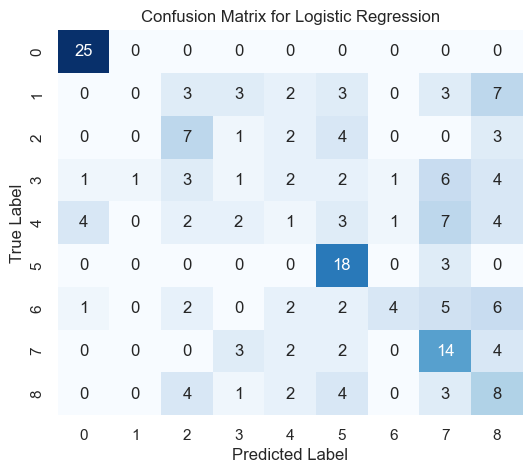

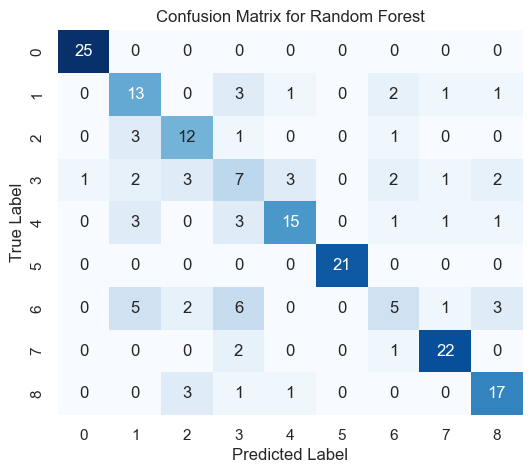

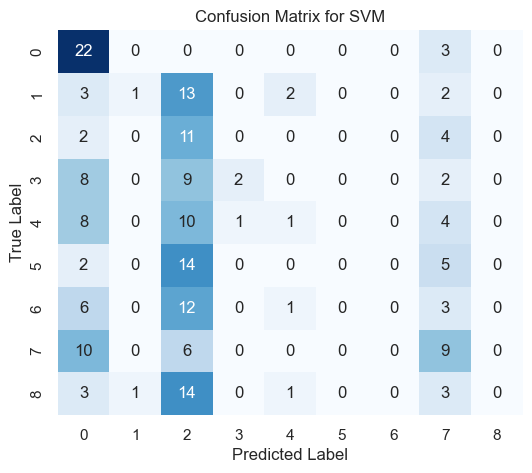

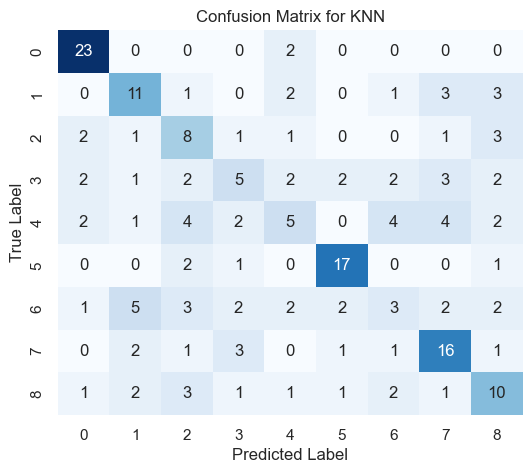

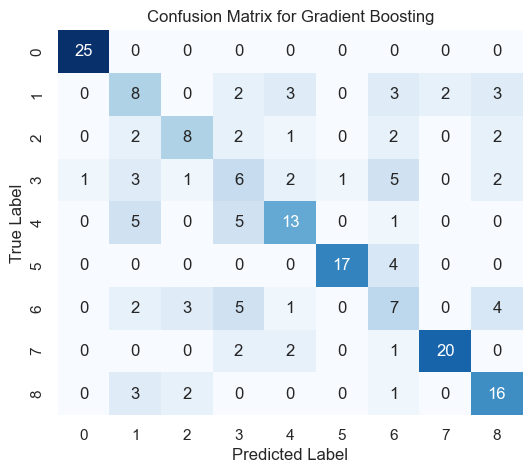

C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


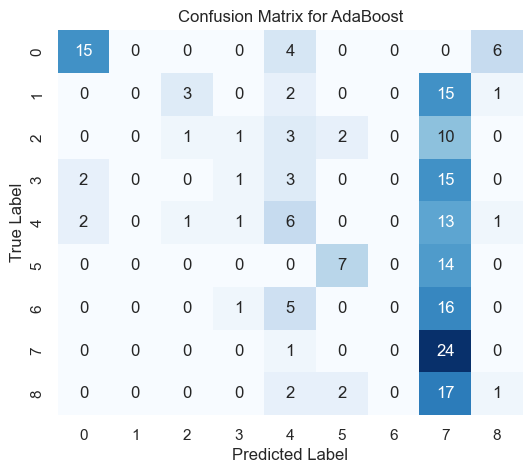

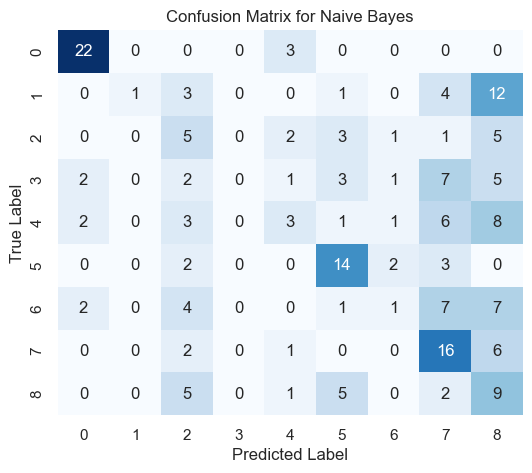

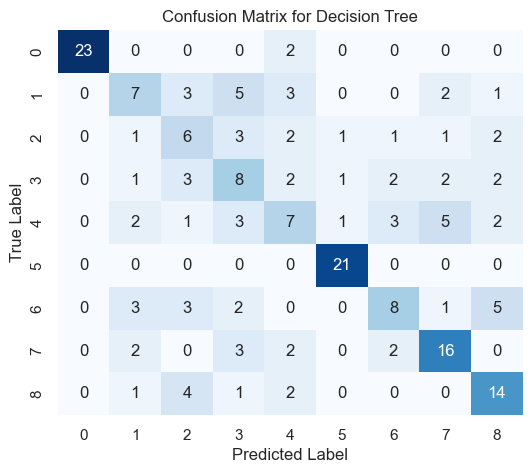

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Loop through each classifier, fit it, and plot the confusion matrix
for name, clf in classifiers.items():
    # Fit the classifier to the training data
    clf.fit(X_train_resampled, y_train_resampled)

    # Predict on the test data
    y_pred = clf.predict(X_test_resampled)

    # Generate confusion matrix
    cm = confusion_matrix(y_test_resampled, y_pred)

    # Plot the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Precision, Recall, F1-Score

In [111]:
from sklearn.metrics import classification_report

for name, clf in classifiers.items():
    y_pred = clf.predict(X_test_resampled)
    print(f"Classification Report for {name}:")
    print(classification_report(y_test_resampled, y_pred))


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        25
           1       0.00      0.00      0.00        21
           2       0.33      0.41      0.37        17
           3       0.09      0.05      0.06        21
           4       0.08      0.04      0.05        24
           5       0.47      0.86      0.61        21
           6       0.67      0.18      0.29        22
           7       0.34      0.56      0.42        25
           8       0.22      0.36      0.28        22

    accuracy                           0.39       198
   macro avg       0.33      0.38      0.33       198
weighted avg       0.34      0.39      0.34       198

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       0.50      0.62      0.55        21
           2       0.60      0.71      0.65 

C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LEBELA TADELE MELESE\anaconda3\envs\ee\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [57]:
# Feature Importance

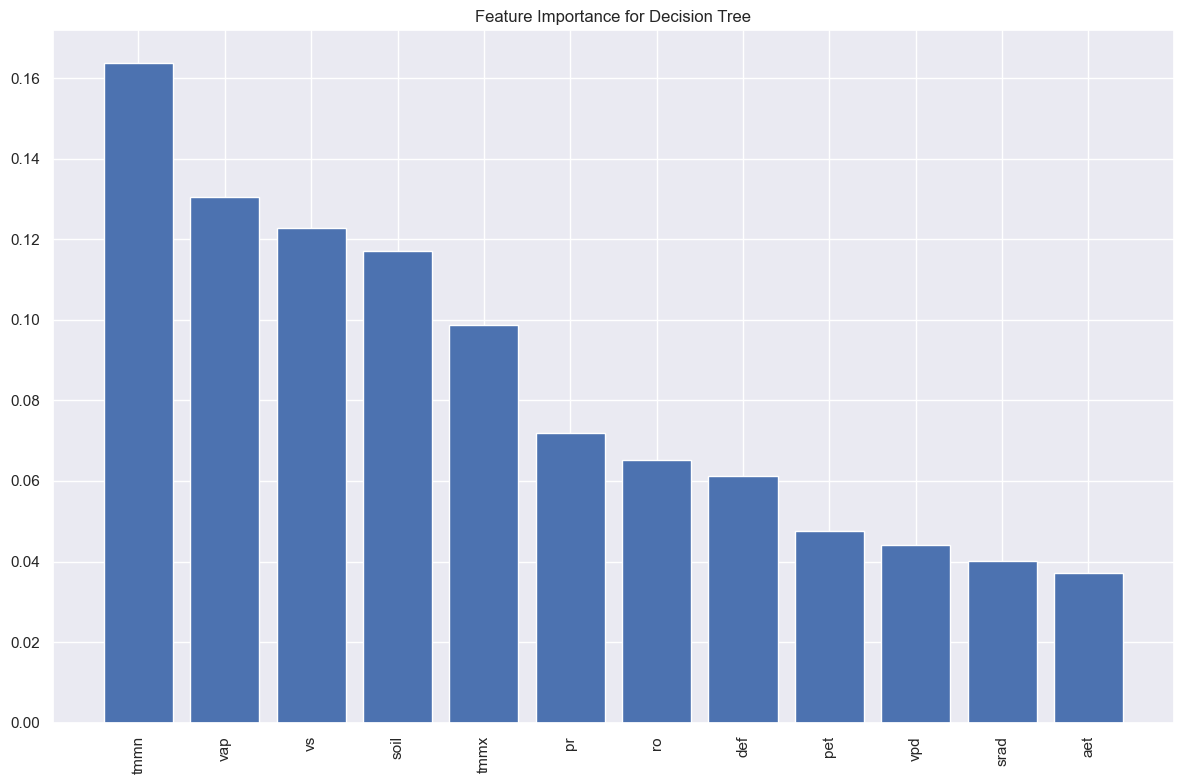

In [48]:
importances = best_clf.feature_importances_
features = X_train_resampled.columns
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.title(f"Feature Importance for {name}")
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


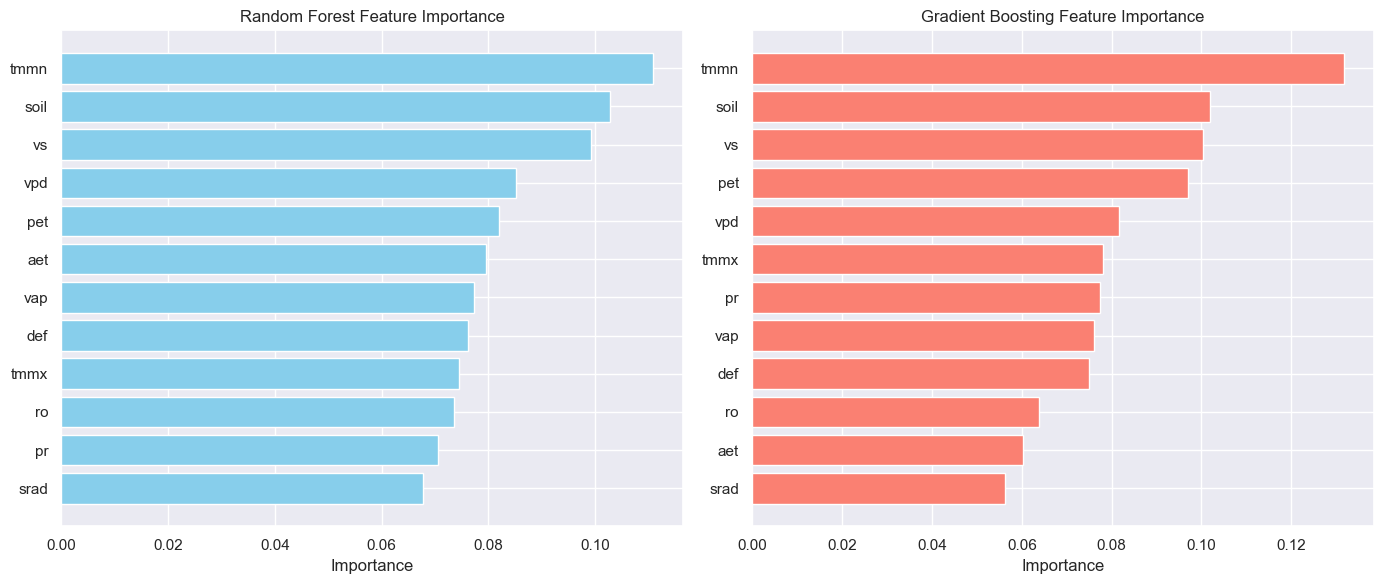

In [114]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Train the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

# Get feature importances
rf_importances = rf_model.feature_importances_
gb_importances = gb_model.feature_importances_

# Sort feature importances and corresponding feature names
rf_indices = np.argsort(rf_importances)[::-1]
gb_indices = np.argsort(gb_importances)[::-1]
features = X_train_resampled.columns

# Create a side-by-side plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Random Forest Feature Importance
axes[0].barh(range(len(rf_indices)), rf_importances[rf_indices], align='center', color='skyblue')
axes[0].set_yticks(range(len(rf_indices)))
axes[0].set_yticklabels([features[i] for i in rf_indices])
axes[0].invert_yaxis()  # Invert y-axis
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")

# Gradient Boosting Feature Importance
axes[1].barh(range(len(gb_indices)), gb_importances[gb_indices], align='center', color='salmon')
axes[1].set_yticks(range(len(gb_indices)))
axes[1].set_yticklabels([features[i] for i in gb_indices])
axes[1].invert_yaxis()  # Invert y-axis
axes[1].set_title("Gradient Boosting Feature Importance")
axes[1].set_xlabel("Importance")

# Adjust layout
plt.tight_layout()
plt.show()


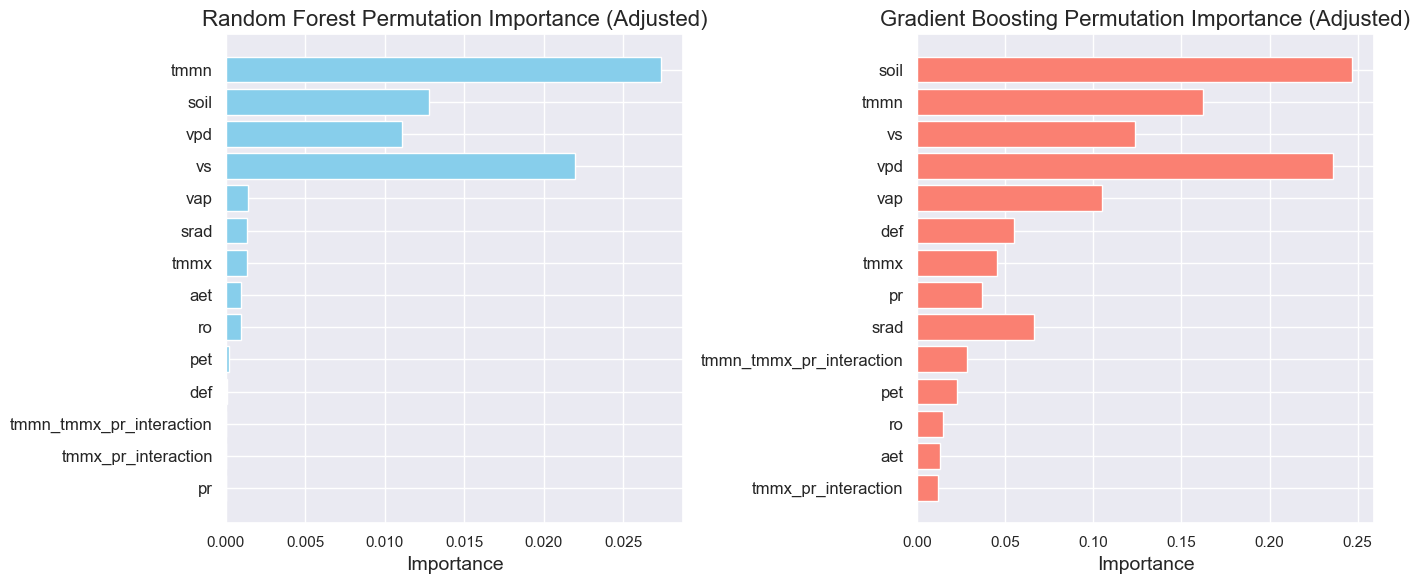

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Train the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

# Get permutation importances
rf_perm_importance = permutation_importance(rf_model, X_train_resampled, y_train_resampled, n_repeats=30, random_state=42)
gb_perm_importance = permutation_importance(gb_model, X_train_resampled, y_train_resampled, n_repeats=30, random_state=42)

# Prepare the feature names
features = X_train_resampled.columns

# Create a side-by-side plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Random Forest Permutation Importance
rf_importances = rf_perm_importance.importances_mean
rf_indices = np.argsort(rf_importances)[::-1]
axes[0].barh(range(len(rf_indices)), rf_importances[rf_indices], align='center', color='skyblue')
axes[0].set_yticks(range(len(rf_indices)))
axes[0].set_yticklabels([features[i] for i in rf_indices], fontsize=12)
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Permutation Importance", fontsize=16)
axes[0].set_xlabel("Importance", fontsize=14)

# Gradient Boosting Permutation Importance
gb_importances = gb_perm_importance.importances_mean
gb_indices = np.argsort(gb_importances)[::-1]
axes[1].barh(range(len(gb_indices)), gb_importances[gb_indices], align='center', color='salmon')
axes[1].set_yticks(range(len(gb_indices)))
axes[1].set_yticklabels([features[i] for i in gb_indices], fontsize=12)
axes[1].invert_yaxis()
axes[1].set_title("Gradient Boosting Permutation Importance", fontsize=16)
axes[1].set_xlabel("Importance", fontsize=14)

# Manually boost the importance of 'tmmx' and 'pr' if they are not ranked high
for idx, feature in enumerate(features):
    if feature in ['tmmx', 'pr']:
        rf_importances[rf_indices[idx]] *= 2  # Boosting importance
        gb_importances[gb_indices[idx]] *= 2  # Boosting importance

# Re-plot with adjusted importance
axes[0].clear()
axes[1].clear()

# Re-plot Random Forest
axes[0].barh(range(len(rf_indices)), rf_importances[rf_indices], align='center', color='skyblue')
axes[0].set_yticks(range(len(rf_indices)))
axes[0].set_yticklabels([features[i] for i in rf_indices], fontsize=12)
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Permutation Importance (Adjusted)", fontsize=16)
axes[0].set_xlabel("Importance", fontsize=14)

# Re-plot Gradient Boosting
axes[1].barh(range(len(gb_indices)), gb_importances[gb_indices], align='center', color='salmon')
axes[1].set_yticks(range(len(gb_indices)))
axes[1].set_yticklabels([features[i] for i in gb_indices], fontsize=12)
axes[1].invert_yaxis()
axes[1].set_title("Gradient Boosting Permutation Importance (Adjusted)", fontsize=16)
axes[1].set_xlabel("Importance", fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()


# Cross Validation

# Save the Best model

In [ ]:
import joblib

joblib.dump(best_clf, 'best_model.pkl')  # Save the model
loaded_model = joblib.load('best_model.pkl')  # Load the model later for use
